#### All Imports

In [97]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import sys
import os
import requests
from bs4 import BeautifulSoup
import io
import time
import re
import glob
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import datetime

import scipy.signal as signal
from scipy.signal import stft, windows

from obspy import read
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

sys.path.append('/data/sswar_files/')
pd.set_option('display.max_columns', None)

from collections import Counter, defaultdict
from scipy.stats import norm
import shap
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist,squareform,cdist
from scipy.cluster import hierarchy
from scipy.stats import spearmanr
from scipy.signal import hilbert

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler, normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score, roc_auc_score, accuracy_score, classification_report, confusion_matrix, root_mean_squared_error, r2_score, mean_squared_error, balanced_accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

from PRJ_SPEC_MASTER.src.utils.data_preparations import *
from PRJ_SPEC_MASTER.src.utils.noise_lib import *
from PRJ_SPEC_MASTER.src.utils.spectograms_lib import *
from PRJ_GIS_QA.src.utils.gisqa_compute_updated import *
from PRJ_GIS_QA.src.utils.helper import *

# events_list = pd.read_csv('/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/metdata/IRIS_DMC_esecEventsDb.txt', delimiter='|')
# events_list

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Utils

In [98]:
def _signalamp_norm(signal_amp):
    signal_amp = 2 * (signal_amp - signal_amp.min()) / (signal_amp.max() - signal_amp.min()) - 1
    return signal_amp

def _log_n_dfa_util(min_n, max_n, factor):
    max_i = int(np.floor(np.log(1.0 * max_n / min_n) / np.log(factor)))
    ns = [min_n]
    for i in range(max_i + 1):
        n = int(np.floor(min_n * (factor**i)))
        if n > ns[-1]:
            ns.append(n)
    return np.array(ns, dtype=np.int64)

def _compute_dfa(x):
    N = len(x)
    nvals = _log_n_dfa_util(4, 0.1 * N, 1.2)
    walk = np.cumsum(x - np.mean(x))
    fluctuations = np.zeros(len(nvals))

    for i_n, n in enumerate(nvals):
        d = np.reshape(walk[: N - (N % n)], (N // n, n))
        ran_n = np.array([float(na) for na in range(n)])
        d_len = len(d)
        trend = np.empty((d_len, ran_n.size))
        for i in range(d_len):
            slope, intercept = np.polyfit(ran_n, d[i], 1) #_linear_regression(ran_n, d[i])
            trend[i, :] = intercept + slope * ran_n
        # Calculate root mean squares of walks in d around trend
        # Note that np.mean on specific axis is not supported by Numba
        flucs = np.sum((d - trend) ** 2, axis=1) / n
        # https://github.com/neuropsychology/NeuroKit/issues/206
        fluctuations[i_n] = np.sqrt(np.mean(flucs))

    # Filter zero
    nonzero = np.nonzero(fluctuations)[0]
    fluctuations = fluctuations[nonzero]
    nvals = nvals[nonzero]
    if len(fluctuations) == 0:
        # all fluctuations are zero => we cannot fit a line
        dfa = np.nan
    else:
        dfa, _ = np.polyfit(np.log(nvals), np.log(fluctuations), 1) #_linear_regression(np.log(nvals), np.log(fluctuations))
    return dfa, np.log(nvals), np.log(fluctuations)

def _clusterimages(data_orig,ncomp=5,image_thresh=75,isplot=0,ts=None,freqs=None):
    #data = list_images[50]
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data_orig.reshape(-1, 1))
    data_nonzero = data[data > np.percentile(data,image_thresh)]

    gmm = GaussianMixture(n_components=ncomp, random_state=6, covariance_type='diag', n_init=5, init_params="k-means++")
    gmm.fit(data_nonzero.reshape(-1, 1))

    plt.figure(figsize=(6, 4))
    plt.hist(data_nonzero, bins=256, density=True, alpha=0.5, label='Histogram (non-zero data)')
    x = np.linspace(data_nonzero.min(), data_nonzero.max(), 1000).reshape(-1, 1)
    pdf = np.zeros_like(x)

    for i in range(ncomp):
        pdf += gmm.weights_[i] * norm.pdf(x, gmm.means_[i, 0], np.sqrt(gmm.covariances_[i, 0]))

    if isplot:
        plt.loglog(x, pdf, 'r-', linewidth=2, label='GMM Fit (5 components)')
        [plt.axvline(x=gmmean[0], color='k', linestyle='--') for gmmean in gmm.means_]
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title('Histogram with 5-Component GMM Fit on Filtered Trace')
        plt.legend()
        plt.show()
    else:
        plt.close()

    cut_locations = sorted(gmm.means_.flatten())

    data_0to1 = data_orig
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_0to1 = scaler.fit_transform(data_0to1.reshape(-1, 1)).reshape(data_0to1.shape)

    labeled_spec_image = np.zeros(data_0to1.shape)
    for i in range (0,len(cut_locations)):
        if i==0:
            labeled_spec_image[data_0to1==0] = i
            labeled_spec_image[(data_0to1>0) & (data_0to1<cut_locations[i].item())] = i
        elif i==len(cut_locations)-1:
            labeled_spec_image[(data_0to1>=cut_locations[i].item())] = i+1
        else:
            labeled_spec_image[(data_0to1>=cut_locations[i].item()) & (data_0to1<cut_locations[i+1].item())] = i+1
    labeled_spec_image = labeled_spec_image.astype(int)

    pafe = pairwise_feature_extractor()
    glszm_stg1, glszm_metrics_stg1 = pafe.compute_pixel_localization_metric(labeled_spec_image)

    if isplot:
        if ts is None and freqs is None:
            plot_freqs = np.linspace(0,50,data_orig.shape[0])
            plot_t = np.linspace(0,10,2500) #np.linspace(0,60,60*100)
        else:
            plot_freqs = freqs
            plot_t = ts

        gisqa_plots.plot_labeled_spec(plot_t,plot_freqs, labeled_spec_image, isplot=1, issave=0)
        gisqa_plots.plot_sizezone_variance_of_labeled_spec(glszm_stg1, isplot=1, issave=0)
    else:
        plt.close()

    return glszm_metrics_stg1

def _perform_hierarchical_clustering(data, method='ward', metric='euclidean', plot_dendrogram=True, color_threshold=None, figsize=(10, 6), savefig=False, savepath=None,VI=None):
    #distance_matrix = cdist(data, data, metric=metric) #pdist(data, metric=metric)
    if VI is not None:
        distance_matrix = pdist(data, metric=metric, VI=inv_cov_matrix)
    else:
        distance_matrix = pdist(data, metric=metric)
    linkage_matrix = linkage(distance_matrix, method=method, optimal_ordering=True)

    #linkage_matrix = linkage(data, method=method, metric=metric, optimal_ordering=True)

    if plot_dendrogram:
        plt.figure(figsize=figsize)
        dendro = dendrogram(linkage_matrix, color_threshold=color_threshold, no_labels=True)            
        plt.title(f'Hierarchical Clustering Dendrogram (method={method}, metric={metric})')
        plt.xlabel('Sample index')
        plt.ylabel('Distance')
        if savefig:
            plt.savefig(savepath, dpi=300)
        plt.show()

    return linkage_matrix #dendro['leaves'], dendro['leaves_color_list'], dendro['color_list']

def _merge_clusters(linkage_matrix, num_clusters=None, distance_threshold=None):
    if num_clusters is not None:
        labels = fcluster(linkage_matrix, t=num_clusters, criterion='maxclust')
    elif distance_threshold is not None:
        labels = fcluster(linkage_matrix, t=distance_threshold, criterion='distance')
    else:
        raise ValueError("You must provide either 'num_clusters' or 'distance_threshold'")
    return labels

def _ghilbertize_asym_data(img):
        #locs = HelperFunc.gilbertize_image(width=self.img_height, height=self.img_width)
        locs = HelperFunc.gilbertize_image_optimized(width=img.shape[0], height=img.shape[1])
        return img[locs[:,0], locs[:,1]].reshape(-1)

def _compute_metric(data, metric_name, dx=3, sf=20):
    """
    Calculates a specific entropy, complexity, or fractal dimension metric 
    based on the provided parameter name.
    
    Parameters:
        data (array): The 1D signal/array to analyze.
        metric_name (str): The name of the metric to compute.
        dx (int): Embedding dimension/order for ordpy and antropy methods.
        sf (float): Sampling frequency, required for spectral entropy.
        
    Returns:
        float: The calculated metric.
    """
    # Normalize the parameter name to lowercase for safe matching
    metric_name = metric_name.lower().strip()
    
    if metric_name == 'permutation_entropy':
        return ordpy.complexity_entropy(data, dx=dx)[0]
        
    elif metric_name == 'svd_entropy':
        return ant.svd_entropy(data, order=dx, normalize=True)
        
    elif metric_name == 'spectral_entropy':
        return ant.spectral_entropy(data, sf=sf, method='welch', normalize=True)
        
    elif metric_name == 'petrosian_fd':
        return ant.petrosian_fd(data)
        
    elif metric_name == 'ant_perm_entropy':
        return ant.perm_entropy(data, order=dx, normalize=True)
        
    elif metric_name == 'hjorth_complexity':
        return ant.hjorth_params(data)[1]
        
    elif metric_name == 'detrended_fluctuation':
        return ant.detrended_fluctuation(data)
        
    elif metric_name == 'global_node_entropy':
        return ordpy.global_node_entropy(data, dx=dx)
        
    elif metric_name == 'fisher_shannon':
        return ordpy.fisher_shannon(data, dx=dx)[1]
        
    elif metric_name == 'missing_patterns':
        return ordpy.missing_patterns(data, dx=dx, return_fraction=True, return_missing=False)
        
    elif metric_name == 'renyi_complexity_entropy':
        return ordpy.renyi_complexity_entropy(data, dx=dx, alpha=3)[0]
        
    elif metric_name == 'tsallis_complexity_entropy':
        return ordpy.tsallis_complexity_entropy(data, dx=dx, q=0.5)[0]
        
    elif metric_name == 'higuchi_fd':
        return ant.higuchi_fd(data)
        
    else:
        raise ValueError(f"Unknown metric name provided: '{metric_name}'")

def _plot_single_feature_distributions(df, label_col='type', features_to_plot=None, use_log_scale=False):
    """
    Iterates through feature columns and generates a combined Boxplot + Stripplot 
    for each feature, grouped by class labels.
    
    Args:
        df (pd.DataFrame): Your dataframe (e.g., sepc2vec_df_filt_picols)
        label_col (str): The column name containing the classes (default: 'type')
        features_to_plot (list): Optional list of specific columns to plot. If None, plots all numeric columns.
        use_log_scale (bool): If True, applies log scale to the X-axis for all plots.
    """
    # 1. Identify which features to plot
    if features_to_plot is None:
        # Grab all numeric columns except the label column
        feature_cols = [col for col in df.columns if col != label_col and pd.api.types.is_numeric_dtype(df[col])]
    else:
        feature_cols = features_to_plot
        
    print(f"Generating plots for {len(feature_cols)} features...")
    
    # 2. Loop through each feature and plot
    for feature in feature_cols:
        
        # Sort classes by their median value for this specific feature
        order = df.groupby(label_col)[feature].median().sort_values().index
        
        # Create the Visualization
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.set_facecolor("#F7F7F7")
        
        # Boxplot (distribution)
        sns.boxplot(
            data=df, 
            x=feature, 
            y=label_col, 
            order=order, 
            palette='nipy_spectral', 
            showfliers=False, 
            ax=ax,
            width=0.5,
            boxprops=dict(alpha=0.5)
        )
        
        # Stripplot (individual points)
        sns.stripplot(
            data=df, 
            x=feature, 
            y=label_col, 
            order=order, 
            color='black', 
            alpha=0.4, 
            size=3.5,
            jitter=0.2, 
            ax=ax
        )
        
        # Labels and Title
        ax.set_title(f"'{feature}' Distribution by {label_col.capitalize()}", fontsize=14, fontweight="bold", pad=12)
        
        x_label = f"{feature} Value"
        if use_log_scale:
            x_label += " (Log Scale)"
            # Safety check: log scale fails on zeros/negatives
            if (df[feature] <= 0).any():
                print(f"⚠️ Warning: '{feature}' contains ≤0 values. Log scale might drop points.")
            ax.set_xscale('log')
            
        ax.set_xlabel(x_label, fontsize=11)
        ax.set_ylabel("Event Type", fontsize=11)
        
        # Clean up axes
        sns.despine(left=True)
        ax.grid(axis='x', linestyle='--', alpha=0.6)
        
        plt.tight_layout()
        plt.show()

def _plot_combined_feature_distributions(df, label_col='type', features_to_plot=None, use_log_scale=False, standardize_features=True, show_point_spreads=False):
    # 1. Identify which features to plot
    if standardize_features:
        all_classes = df[label_col].values
        df_scaled = StandardScaler().fit_transform(df.drop(columns=[label_col]))
        df = pd.DataFrame(df_scaled, columns=df.drop(columns=[label_col]).columns, index=df.drop(columns=[label_col]).index)
        df[f'{label_col}'] = all_classes
        del df_scaled

    if features_to_plot is None:
        feature_cols = [col for col in df.columns if col != label_col and pd.api.types.is_numeric_dtype(df[col])]
    else:
        feature_cols = features_to_plot
        
    print(f"Generating combined plot for {len(feature_cols)} features...")
    
    # 2. Reshape the dataframe from "wide" to "long" format
    # This creates a 'Feature_Name' column for the X-axis and a 'Value' column for the Y-axis
    melted_df = df.melt(id_vars=[label_col], value_vars=feature_cols, 
                        var_name='Feature_Name', value_name='Value')
    
    # 3. Create the Visualization
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_facecolor("#F7F7F7")
    
    # Boxplot (distribution)
    # Using 'hue' creates the side-by-side grouping per feature
    sns.boxplot(
        data=melted_df, 
        x='Feature_Name', 
        y='Value', 
        hue=label_col, 
        palette='nipy_spectral', 
        showfliers=False, 
        ax=ax,
        width=0.6,
        boxprops=dict(alpha=0.5)
    )
    
    # Stripplot (individual points)
    # dodge=True makes the points align perfectly over their corresponding grouped boxplot
    if show_point_spreads:
        sns.stripplot(
            data=melted_df, 
            x='Feature_Name', 
            y='Value', 
            hue=label_col, 
            color='black', 
            alpha=0.4, 
            size=3.5,
            jitter=0.2,
            dodge=True,
            ax=ax
        )
    
    # Labels and Title
    ax.set_title("Feature Distributions by Event Type", fontsize=16, fontweight="bold", pad=12)
    ax.set_xlabel("Feature Name", fontsize=12, labelpad=10)
    
    # Apply log scale if requested (Applied to the Y-axis now)
    y_label = "Feature Value"
    if use_log_scale:
        y_label += " (Log Scale)"
        if (melted_df['Value'] <= 0).any():
            print("⚠️ Warning: Some features contain ≤0 values. Log scale might drop those points.")
        ax.set_yscale('log')
        
    ax.set_ylabel(y_label, fontsize=12)
    
    # Clean up legend (stripplot adds duplicate legends, so we fix it to only show the boxplot legend)
    handles, labels = ax.get_legend_handles_labels()
    num_classes = len(df[label_col].unique())
    ax.legend(handles[:num_classes], labels[:num_classes], title="Event Type", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Rotate X-axis labels in case feature names are long
    plt.xticks(rotation=15, ha='right')
    
    # Clean up axes
    sns.despine(left=True)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def _plot_interpretability_grid(df, ref_features: list, complex_target: str, class_col: str = 'Type', xlim=None, ylim=None, xlim_contour=None, ylim_contour=None,
                                refscale_log=False, kdelog=False):
    
    num_refs = len(ref_features)
    
    # Scale figure height dynamically based on the number of reference features
    fig, axes = plt.subplots(nrows=num_refs, ncols=2, figsize=(14, 5.5 * num_refs))
    
    # Safety catch: if only 1 reference feature is passed, Matplotlib returns a 1D array. 
    # We force it to 2D so our looping logic doesn't break.
    if num_refs == 1:
        axes = np.array([axes])
        
    # Generate a consistent color palette for all subplots
    unique_classes = df[class_col].unique()
    palette = sns.color_palette("tab10", n_colors=len(unique_classes))
    
    for i, ref_feat in enumerate(ref_features):
        ax_scatter = axes[i, 0]
        ax_kde = axes[i, 1]

        # ==========================================
        # 1. SCATTER PLOT (Raw Distribution)
        # ==========================================
        sns.scatterplot(
            data=df, 
            x=ref_feat, 
            y=complex_target, 
            hue=class_col, 
            palette=palette,
            alpha=0.6,          # Slight transparency to see overlapping dots
            edgecolor='black',  # Crisp borders for print readability
            linewidth=0.4,
            s=40,
            ax=ax_scatter,
            legend=False        # Hide legend to avoid drawing it 10 times
        )
        
        ax_scatter.set_title(f"Scatter: {complex_target} \nvs. {ref_feat}", fontsize=11, fontweight='bold')
        ax_scatter.set_ylabel(complex_target, fontsize=10)
        ax_scatter.set_xlabel(ref_feat, fontsize=10)
        ax_scatter.grid(True, linestyle='--', alpha=0.5)
        if xlim:
            ax_scatter.set_xlim(xlim)
        if ylim:
            ax_scatter.set_ylim(ylim)
        if refscale_log:
            ax_scatter.set_yscale('log')
            ax_scatter.set_xscale('log')

        sns.despine(ax=ax_scatter)

        # ==========================================
        # 2. KDE CONTOUR PLOT (Density/Territory)
        # ==========================================
        sns.kdeplot(
            data=df, 
            x=ref_feat, 
            y=complex_target, 
            hue=class_col, 
            palette=palette,
            fill=True, 
            alpha=0.3, 
            levels=5,           # 5 contour rings per class
            warn_singular=False,# Prevents crashing if a class has too few samples
            ax=ax_kde,
            legend=(i == 0),     # ONLY draw the legend on the very first KDE plot,
            log_scale=kdelog
        )
        
        ax_kde.set_title(f"KDE Density: {complex_target} \nvs. {ref_feat}", fontsize=11, fontweight='bold')
        ax_kde.set_ylabel(complex_target, fontsize=10)
        ax_kde.set_xlabel(ref_feat, fontsize=10)
        ax_kde.grid(True, linestyle='--', alpha=0.5)
        if xlim_contour:
            ax_kde.set_xlim(xlim_contour)
        if ylim_contour:
            ax_kde.set_ylim(ylim_contour)
        # if refscale_log:
        #     ax_kde.set_yscale('log')
        #     ax_kde.set_xscale('log')
        sns.despine(ax=ax_kde)
        
        if i == 0:
            sns.move_legend(
                ax_kde, 
                "upper left", 
                bbox_to_anchor=(1.05, 1), 
                title="Event Classes",
                frameon=False,
                fontsize=10
            )
    plt.tight_layout()
    plt.show()

def _plot_1dhilbert_dashboard(archetype_labels:list, spectro_dict:dict, metric_name:str="detrended_fluctuation", dx:int=None, clean_names:list=[]):
    """
    Plots a 3-column dashboard:
    Col 1: Spectrogram (1 per archetype)
    Col 2: 1D Time Series (2 per archetype: Flattened top, Hilbert bottom)
    Col 3: Bar Charts (2 overall: Flattened top half, Hilbert bottom half)
    """
    N = len(archetype_labels)
    if len(clean_names)>0:
        assert len(clean_names) == N, "class lables must match archetype labels"
    
    fig = plt.figure(figsize=(20, 3.5 * N))
    gs = gridspec.GridSpec(2 * N, 3, figure=fig, width_ratios=[1.2, 3.5, 1.2], wspace=0.3, hspace=0.5)

    flat_entropies = []
    hilb_entropies = []
    colors = ['#2ca02c', '#ff7f0e', '#9467bd', '#8c564b','#d62728', '#1f77b4','#1f77b4','#d62728'][:N] 
    
    # ==========================================
    # POPULATE COLUMNS 1 & 2 (Per Archetype)
    # ==========================================
    for i, label in enumerate(archetype_labels):
        spectro = spectro_dict.get(label)
        
        # Clean up the label for titles
        if len(clean_names)==0:
            parts = label.split('_')
            clean_name = " ".join([p for p in parts[2:-5] if p.islower()]).title()
            clean_names.append(clean_name)
        else:
            clean_name=clean_names[i]
        
        # ------------------------------------------
        # COLUMN 1: Spectrogram (Spans 2 sub-rows)
        # ------------------------------------------
        ax_spec = fig.add_subplot(gs[2*i : 2*i+2, 0])
        
        if spectro is not None:
            spectro_mag = np.abs(spectro)
            # Apply the 75% Threshold Noise Gate
            spectro_mag[spectro_mag < np.percentile(spectro_mag, 50)] = 0
            
            ax_spec.imshow(spectro_mag, aspect='auto', origin='lower', cmap='viridis')
            
            if i == 0:
                ax_spec.set_title("Thresholded CWT", fontsize=10, fontweight='bold', pad=10)
            ax_spec.set_ylabel(f"{clean_name}\nFreq Bins", fontweight='bold')
            ax_spec.set_xlabel("Time Bins")
            
            flat_data = spectro_mag.flatten()
            hilb_data = _ghilbertize_asym_data(spectro_mag)
            
            ent_flat = _compute_metric(flat_data,metric_name,dx=dx)
            ent_hilb = _compute_metric(hilb_data,metric_name,dx=dx)
            
            flat_entropies.append(ent_flat)
            hilb_entropies.append(ent_hilb)

            # ------------------------------------------
            # COLUMN 2 (Top): Flattened 1D Time Series
            # ------------------------------------------
            ax_line_flat = fig.add_subplot(gs[2*i, 1])
            ax_line_flat.plot(flat_data, color=colors[i], linewidth=0.3, alpha=0.5)
            ax_line_flat.set_ylabel("Flatten", fontsize=10, fontweight='bold', color='k')
            ax_line_flat.set_xticks([]) # Hide X-ticks to keep it clean
            ax_line_flat.margins(x=0)
            
            if i == 0:
                ax_line_flat.set_title("1D Linearization Topology", fontsize=10, fontweight='bold', pad=10)

            # ------------------------------------------
            # COLUMN 2 (Bottom): Hilbert 1D Time Series
            # ------------------------------------------
            ax_line_hilb = fig.add_subplot(gs[2*i+1, 1])
            ax_line_hilb.plot(hilb_data, color=colors[i], linewidth=0.3, alpha=1)
            ax_line_hilb.set_ylabel("Hilbert", fontsize=10, fontweight='bold', color='k')
            ax_line_hilb.set_xticks([])
            ax_line_hilb.margins(x=0)
            
        else:
            flat_entropies.append(0)
            hilb_entropies.append(0)
            ax_spec.text(0.5, 0.5, "Data Missing", ha='center', va='center')

    # ==========================================
    # POPULATE COLUMN 3 (Spans all rows, divided by 2)
    # ==========================================
    # Top Half of Column 3 (Rows 0 to N)
    ax_bar_flat = fig.add_subplot(gs[0:N, 2])
    # Bottom Half of Column 3 (Rows N to 2N)
    ax_bar_hilb = fig.add_subplot(gs[N:2*N, 2])
    
    x_pos = np.arange(N)
    
    # ------------------------------------------
    # COLUMN 3 (Top): Flattened Bar Chart
    # ------------------------------------------
    ax_bar_flat.bar(x_pos, flat_entropies, color=colors, edgecolor='black', alpha=0.5, width=0.6)
    ax_bar_flat.set_xticks([])
    #ax_bar_flat.set_xticklabels(clean_names, rotation=25, ha='right', fontsize=11)
    ax_bar_flat.set_title(f"Standard Flatten\n{metric_name} Results", fontsize=9, fontweight='bold')
    ax_bar_flat.set_ylabel(metric_name)
    ax_bar_flat.grid(axis='y', linestyle='--', alpha=0.6)
    ax_bar_flat.set_yscale('log') # Uncomment if metric requires log scale

    # ------------------------------------------
    # COLUMN 3 (Bottom): Hilbert Bar Chart
    # ------------------------------------------
    ax_bar_hilb.bar(x_pos, hilb_entropies, color=colors, edgecolor='black', alpha=1, width=0.6)
    ax_bar_hilb.set_xticks(x_pos)
    ax_bar_hilb.set_xticklabels(clean_names, rotation=25, ha='right', fontsize=9)
    ax_bar_hilb.set_title(f"Hilbert Curve\n{metric_name} Results", fontsize=9, fontweight='bold')
    ax_bar_hilb.set_ylabel(metric_name)
    ax_bar_hilb.grid(axis='y', linestyle='--', alpha=0.6)
    ax_bar_hilb.set_yscale('log') # Uncomment if metric requires log scale

    # Final cleanup to ensure labels don't overlap
    plt.tight_layout()
    plt.show()

def _plot_comprehensive_4row_dashboard(archetype_labels, archetype_subtype, spectro_dict, data_dir_lst, fs=20.0, dx_spec=5, dx_ts=5, dx_fft=5, spec_noise_thresh=75, 
                                        metric_name="Complexity Entp", save_path=None):
    N = len(archetype_labels)
    
    # Create figure and a GridSpec layout
    # Width scales dynamically with N. Height increased to accommodate 4 rows.
    fig = plt.figure(figsize=(4 * N, 14))
    

    # Height ratios: TS (1), TS/FFT Bars (1.2), Spectro (1), CWT Bars (1.2)
    # gs = gridspec.GridSpec(4, 2 * N, figure=fig, height_ratios=[1.0, 1.2, 1.0, 1.2])
    gs = gridspec.GridSpec(5, 2 * N, figure=fig, height_ratios=[1.0, 1.0, 1.2, 1.0, 1.2])

    # Storage arrays for the 4 bar charts
    ts_entropies = []
    fft_entropies = []
    flat_entropies = []
    hilb_entropies = []
    clean_names = []
    
    colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#8f0b8a'][:N] # Red, Blue, Green, Orange
    
    # ==========================================
    # DATA EXTRACTION & ROW 1/ROW 3 PLOTTING
    # ==========================================
    for i, (label,subtyp) in enumerate(zip(archetype_labels,archetype_subtype)):
        # 1. Clean up the label for titles
        parts = label.split('_')
        clean_name = " ".join([p for p in parts[2:-5] if p.islower()]).title() if subtyp != "Tectonic Eathquakes" else "Tectonic Eathquakes"
        clean_names.append(clean_name)
        
        # 2. Fetch Time Series
        filename = label[label.find('_')+1:] + '.sac' if subtyp != "Tectonic Eathquakes" else label + '.sac'
        data_dir = data_dir_lst[0] if subtyp != "Tectonic Eathquakes" else data_dir_lst[1]
        filepath = os.path.join(data_dir, filename)
        
        if os.path.exists(filepath):
            st = read(filepath)
            tr_data = st[0].copy()
            if fs != tr_data.stats.sampling_rate:
                tr_data.interpolate(sampling_rate=fs, method='lanczos', a=20)
            signal = tr_data.data
            signal =  _signalamp_norm(signal) 
            time_vector = np.linspace(0, len(signal)/fs, len(signal))
            
            # 3. Fetch FFT
            fft_f, sigfft_tmp = signal_spectra(signal, fs)
            fft_mask = (fft_f >= 1) & (fft_f <= 5)
            fft_f = fft_f[fft_mask]
            sigfft_tmp = sigfft_tmp[fft_mask]
        else:
            signal = np.zeros(100)
            time_vector = np.linspace(0, 100/fs, 100)
            sigfft_tmp = np.zeros(100)
            
        # 4. Fetch Spectro 
        spectro = spectro_dict.get(label)
        spectro_mag = np.abs(spectro)
        spectro_mag[spectro_mag < np.percentile(spectro_mag, spec_noise_thresh)] = 0
        flat_spec_data = spectro_mag.flatten()
        hilb_spec_data = _ghilbertize_asym_data(spectro_mag)

        # ------------------------------------------
        # COMPUTE METRICS
        # ------------------------------------------
        ts_len = len(signal)
        fft_len = len(sigfft_tmp)
        spec_len = len(flat_spec_data)

        ent_ts = _compute_metric(signal, metric_name, dx=dx_ts)
        ent_fft = _compute_metric(sigfft_tmp, metric_name, dx=dx_fft)
        ent_flat = _compute_metric(flat_spec_data, metric_name, dx=dx_spec)
        ent_hilb = _compute_metric(hilb_spec_data, metric_name, dx=dx_spec)
        
        ts_entropies.append(ent_ts)
        fft_entropies.append(ent_fft)
        flat_entropies.append(ent_flat)
        hilb_entropies.append(ent_hilb)
        
        # ------------------------------------------
        # ROW 1: TIME SERIES PLOT
        # ------------------------------------------
        ax_ts = fig.add_subplot(gs[0, i*2 : (i+1)*2])
        ax_ts.plot(time_vector, signal, color='black', linewidth=0.5)
        ax_ts.set_title(f"TS, {clean_name} (N={ts_len})", fontsize=11, fontweight='bold', pad=10)
        ax_ts.set_ylabel("Velocity")
        ax_ts.set_xlim([0, time_vector[-1]])
        ax_ts.set_xticks([]) # Keep clean for the dashboard look

        # ------------------------------------------
        # ROW 2: FFT PLOT (1-5 Hz)
        # ------------------------------------------
        ax_fft = fig.add_subplot(gs[1, i*2 : (i+1)*2])
        ax_fft.plot(fft_f, sigfft_tmp, color='navy', linewidth=1.2)
        ax_fft.set_title(f"FFT, {clean_name} (N={fft_len})", fontsize=11, fontweight='bold', pad=10)
        ax_fft.set_ylabel("Amplitude")
        ax_fft.set_xlim([1, 5])
        ax_fft.set_xticks([1, 2, 3, 4, 5])
        ax_fft.set_xticklabels(['1Hz', '2Hz', '3Hz', '4Hz', '5Hz'])
        

        # ------------------------------------------
        # ROW 3: SPECTROGRAM PLOT
        # ------------------------------------------
        ax_spec = fig.add_subplot(gs[3, i*2 : (i+1)*2])
        
        ax_spec.imshow(spectro_mag, aspect='auto', origin='lower', cmap='viridis')
        ax_spec.set_title(f"CWT {clean_name}\nN={spec_len}, Thresh {spec_noise_thresh}%", fontsize=11, fontweight='bold')
        ax_spec.set_ylabel("Freq Bins")
        ax_spec.set_xlabel("Time Bins")
        
        
    # ==========================================
    # ROW 2: TIME SERIES & FFT BAR CHARTS
    # ==========================================
    x_pos = np.arange(N)
    
    # Left: Time Series Metric
    ax_bar_ts = fig.add_subplot(gs[2, 0:N])
    ax_bar_ts.bar(x_pos, ts_entropies, color=colors, edgecolor='black', alpha=0.8, width=0.6)
    ax_bar_ts.set_xticks(x_pos)
    ax_bar_ts.set_xticklabels(clean_names, rotation=15, ha='right', fontsize=10)
    ax_bar_ts.set_title(f"Time Series, {metric_name}", fontsize=11, fontweight='bold', pad=10)
    ax_bar_ts.set_ylabel(f"Value (dx={dx_ts})")
    ax_bar_ts.grid(axis='y', linestyle='--', alpha=0.6)
    ax_bar_ts.set_yscale('log')

    # Right: FFT Metric
    ax_bar_fft = fig.add_subplot(gs[2, N:2*N])
    ax_bar_fft.bar(x_pos, fft_entropies, color=colors, edgecolor='black', alpha=0.8, width=0.6)
    ax_bar_fft.set_xticks(x_pos)
    ax_bar_fft.set_xticklabels(clean_names, rotation=15, ha='right', fontsize=10)
    ax_bar_fft.set_title(f"FFT, {metric_name}", fontsize=11, fontweight='bold', pad=10)
    ax_bar_fft.set_ylabel(f"Value (dx={dx_fft})")
    ax_bar_fft.grid(axis='y', linestyle='--', alpha=0.6)
    ax_bar_fft.set_yscale('log')

    # ==========================================
    # ROW 4: CWT FLATTEN VS HILBERT BAR CHARTS
    # ==========================================
    # Left: Standard Flatten
    ax_bar_flat = fig.add_subplot(gs[4, 0:N])
    ax_bar_flat.bar(x_pos, flat_entropies, color=colors, edgecolor='black', alpha=0.8, width=0.6)
    ax_bar_flat.set_xticks(x_pos)
    ax_bar_flat.set_xticklabels(clean_names, rotation=15, ha='right', fontsize=10)
    ax_bar_flat.set_title(f"CWT Standard Flatten (Row-by-Row)\n{metric_name}", fontweight='bold', pad=10)
    ax_bar_flat.set_ylabel(f"Value (dx={dx_spec})")
    ax_bar_flat.grid(axis='y', linestyle='--', alpha=0.6)
    ax_bar_flat.set_yscale('log')

    # Right: Hilbert Curve
    ax_bar_hilb = fig.add_subplot(gs[4, N:2*N])
    ax_bar_hilb.bar(x_pos, hilb_entropies, color=colors, edgecolor='black', alpha=0.8, width=0.6)
    ax_bar_hilb.set_xticks(x_pos)
    ax_bar_hilb.set_xticklabels(clean_names, rotation=15, ha='right', fontsize=10)
    ax_bar_hilb.set_title(f"CWT Hilbert Space-Filling Curve\n{metric_name}", fontweight='bold', pad=10)
    ax_bar_hilb.set_ylabel(f"Value (dx={dx_spec})")
    ax_bar_hilb.grid(axis='y', linestyle='--', alpha=0.6)
    ax_bar_hilb.set_yscale('log')

    # Cleanup and display
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.6) # Ensure titles and x-labels don't overlap
    if save_path:
        plt.savefig(save_path)
        plt.close()
    plt.show()

def _plot_dfa_details_panel_crossover(labels_to_plot, data_dir, spectro_dict, fs):
    num_cols = len(labels_to_plot)
    
    # Set up a 3-row grid. 
    fig, axes = plt.subplots(
        nrows=3, ncols=num_cols, 
        figsize=(4 * num_cols, 10), 
        gridspec_kw={'height_ratios': [1, 1.5, 1.5]}
    )
    
    if num_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for col_idx, spec2vec_label in enumerate(labels_to_plot):
        # Extract clean name
        parts = spec2vec_label.split('_')
        class_parts = [p for p in parts[2:-5] if p.islower()] 
        clean_name = " ".join(class_parts).title()
        
        # 1. Fetch Data
        filename = spec2vec_label[spec2vec_label.find('_')+1:] + '.sac'
        filepath = os.path.join(data_dir, filename)
        
        if not os.path.exists(filepath): continue

        try:   
            st = read(filepath)
        except Exception as e:
            return print(f"Error reading trace: {e}")

        tr_data = st[0].copy()
        if fs != tr_data.stats.sampling_rate:
            tr_data.interpolate(sampling_rate=fs, method='lanczos', a=20)
        tr_data = _signalamp_norm(tr_data.data) 
            
        signal = tr_data.copy()
        time_vector = np.linspace(0, len(signal)/fs, len(signal))
        spectro = spectro_dict.get(spec2vec_label)
        spectro_hilb = _ghilbertize_asym_data(np.abs(spectro))
        
        # Invoke DFA (Assuming compute_dfa is in scope)
        slopeW, log_scalesW, log_rmsW = _compute_dfa(spectro_hilb)

        # ==========================================
        # ROW 1: RAW WAVEFORM
        # ==========================================
        ax_wave = axes[0, col_idx]
        ax_wave.plot(time_vector, signal, color='black', linewidth=0.5)
        ax_wave.set_title(f"{clean_name}", fontsize=14, fontweight='bold', pad=10)
        ax_wave.set_xlim([0, time_vector[-1]])
        ax_wave.axis('off') 

        # ==========================================
        # ROW 2: CWT SPECTROGRAM
        # ==========================================
        ax_spec = axes[1, col_idx]
        if spectro is not None:
            extent = [0, time_vector[-1], 0.5, 8.0]
            ax_spec.imshow(np.abs(spectro), aspect='auto', origin='lower', extent=extent, cmap='viridis')
            ax_spec.set_ylabel("Freq (Hz)" if col_idx == 0 else "")
            ax_spec.set_xlabel("Time (s)")
        else:
            ax_spec.text(0.5, 0.5, "Missing", ha='center', va='center')

        # ==========================================
        # ROW 3: DFA TWO-REGIME LOG-LOG PLOT
        # ==========================================
        ax_dfa = axes[2, col_idx]
        
        # Scatter the actual log-log fluctuation points
        ax_dfa.scatter(
            log_scalesW, log_rmsW, 
            edgecolor='black', facecolor='dodgerblue', 
            alpha=0.6, s=30, label='Fluctuation $F(n)$', zorder=2
        )
        
        # --- THE CROSSOVER LOGIC ---
        crossover_point = 3.0 # log10(n) = 3 (Window size of 1000 samples)
        log_scalesW_arr = np.array(log_scalesW)
        log_rmsW_arr = np.array(log_rmsW)
        
        # Mask for Regime 1: Short-Range (The actual physics)
        mask_short = log_scalesW_arr <= crossover_point
        x_short, y_short = log_scalesW_arr[mask_short], log_rmsW_arr[mask_short]
        
        # Mask for Regime 2: Long-Range Saturation
        mask_long = log_scalesW_arr >= crossover_point
        x_long, y_long = log_scalesW_arr[mask_long], log_rmsW_arr[mask_long]
        
        # Fit and plot Regime 1 (Short-Range)
        if len(x_short) > 1:
            fit_short = np.polyfit(x_short, y_short, 1)
            line_short = fit_short[0] * x_short + fit_short[1]
            ax_dfa.plot(x_short, line_short, color='red', linestyle='-', linewidth=2.5, 
                        label=f'Short-Range Physics ($\u03B1_1$ = {fit_short[0]:.2f})', zorder=3)
            
        # Fit and plot Regime 2 (Long-Range Saturation)
        if len(x_long) > 1:
            fit_long = np.polyfit(x_long, y_long, 1)
            line_long = fit_long[0] * x_long + fit_long[1]
            ax_dfa.plot(x_long, line_long, color='darkorange', linestyle='--', linewidth=2, 
                        label=f'Finite Saturation ($\u03B1_2$ = {fit_long[0]:.2f})', zorder=3)
            
        # Draw the physical crossover boundary
        ax_dfa.axvline(x=crossover_point, color='gray', linestyle=':', linewidth=1.5, 
                       label=f'Crossover ($10^{{{int(crossover_point)}}}$)', zorder=1)
        
        # Formatting
        ax_dfa.set_xlabel("Log Window Size $\\log_{10}(n)$")
        if col_idx == 0:
            ax_dfa.set_ylabel("Log Fluctuation $\\log_{10}(F(n))$")
        
        ax_dfa.grid(True, linestyle=':', alpha=0.6)
        
        # Adjust legend to fit all the new lines
        ax_dfa.legend(loc='lower right', frameon=True, fontsize=8)
        sns.despine(ax=ax_dfa)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3) 
    plt.show()

def _plot_dfa_details_panel(labels_to_plot, data_dir, spectro_dict, fs):
    num_cols = len(labels_to_plot)
    
    # Set up a 3-row grid. 
    # Height ratios make the waveform/spectro standard size, and the DFA plot slightly taller.
    fig, axes = plt.subplots(
        nrows=3, ncols=num_cols, 
        figsize=(4 * num_cols, 10), 
        gridspec_kw={'height_ratios': [1, 1.5, 1.5]}
    )
    
    # Handle edge case where there is only 1 label (axes becomes 1D)
    if num_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for col_idx, spec2vec_label in enumerate(labels_to_plot):
        parts = spec2vec_label.split('_')
        class_parts = [p for p in parts[2:-5] if p.islower()] 
        clean_name = " ".join(class_parts).title()
        
        # 1. Fetch the Data
        filename = spec2vec_label[spec2vec_label.find('_')+1:] + '.sac'
        filepath = os.path.join(data_dir, filename)
        
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
            
        st = read(filepath)
        tr_data = st[0].copy()
        current_fs = tr_data.stats.sampling_rate
        
        if fs != current_fs:
            tr_data.interpolate(sampling_rate=fs, method='lanczos', a=20)
            
        signal = _signalamp_norm(tr_data.data) 
        time_vector = np.linspace(0, len(signal)/fs, len(signal))
        spectro = spectro_dict.get(spec2vec_label)
        spectro_hilb = _ghilbertize_asym_data(np.abs(spectro))
        
        # Invoke your DFA function
        # (Assuming compute_dfa is already loaded in your environment)
        slopeW, log_scalesW, log_rmsW = _compute_dfa(spectro_hilb)

        # ==========================================
        # ROW 1: RAW WAVEFORM
        # ==========================================
        ax_wave = axes[0, col_idx]
        ax_wave.plot(time_vector, signal, color='black', linewidth=0.5)
        ax_wave.set_title(f"{clean_name}", fontsize=14, fontweight='bold', pad=10)
        ax_wave.set_xlim([0, time_vector[-1]])
        ax_wave.axis('off') # Turn off axes for waveform to look cleaner

        # ==========================================
        # ROW 2: CWT SPECTROGRAM
        # ==========================================
        ax_spec = axes[1, col_idx]
        if spectro is not None:
            # Assuming spectro is shape (freq_bins, time_bins) and frequency is 0.5 to 8Hz
            extent = [0, time_vector[-1], 0.5, 8.0]
            im = ax_spec.imshow(
                np.abs(spectro), 
                aspect='auto', 
                origin='lower', 
                extent=extent, 
                cmap='viridis'
            )
            ax_spec.set_ylabel("Freq (Hz)" if col_idx == 0 else "")
            ax_spec.set_xlabel("Time (s)")
            ax_spec.tick_params(labelsize=9)
        else:
            ax_spec.text(0.5, 0.5, "Spectrogram Missing", ha='center', va='center')

        # ==========================================
        # ROW 3: DFA LOG-LOG PLOT
        # ==========================================
        ax_dfa = axes[2, col_idx]
        
        # Scatter the actual log-log fluctuation points
        ax_dfa.scatter(
            log_scalesW, log_rmsW, 
            edgecolor='black', facecolor='dodgerblue', 
            alpha=0.7, s=30, label='Fluctuation $F(n)$'
        )
        
        # Calculate and draw the linear fit line
        # polyfit returns [slope, intercept]
        fit = np.polyfit(log_scalesW, log_rmsW, 1) 
        fit_line = fit[0] * np.array(log_scalesW) + fit[1]
        print('computed slope:',fit[0])
        
        ax_dfa.plot(
            log_scalesW, fit_line, 
            color='red', linestyle='--', linewidth=2, 
            label=f'Fit ($\u03B1$ = {slopeW:.3f})'
        )
        
        ax_dfa.set_xlabel("Log Window Size $\\log_{10}(n)$")
        if col_idx == 0:
            ax_dfa.set_ylabel("Log Fluctuation $\\log_{10}(F(n))$")
        
        ax_dfa.grid(True, linestyle=':', alpha=0.6)
        ax_dfa.legend(loc='lower right', frameon=True, fontsize=9)
        sns.despine(ax=ax_dfa)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3) 
    plt.show()


#### Load File

In [99]:
master_cat = pd.read_csv('/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/Master_ESEC_Catalog_vel_all.csv')
master_cat['Net_Stn'] = master_cat['StationNetwork']+'.'+master_cat['StationName']
master_cat_all_types = master_cat['Type']
master_cat_all_SNR = master_cat['SNR']
master_cat_stndist = master_cat['StationDistance']
master_cat_net_stn = master_cat['Net_Stn']

esec_event_cat = pd.read_csv('/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/metadata/IRIS_DMC_esecEventsDb.txt', delimiter='|')
print("esec_event_cat:", esec_event_cat.shape)

sepc2vec_df = pd.read_csv('/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/computed_dataset_files/esec_spec2vec_metrics_spatial.csv')
sepc2vec_df = sepc2vec_df.drop(columns=['TS_renyi_complexity_entropy_short_ordpy','FFT_renyi_complexity_entropy_short_ordpy','SPEC_renyi_complexity_entropy_short_ordpy',
                                        'TS_renyi_stat_complexity_short_ordpy','FFT_renyi_stat_complexity_short_ordpy','SPEC_renyi_stat_complexity_short_ordpy'])
print("Original sepc2vec_df:", sepc2vec_df.shape)
sepc2vec_df['Eventid'] = [label.split('_')[1] for label in sepc2vec_df['label']]
sepc2vec_df['MasterCatIdx'] = [label.split('_')[0] for label in sepc2vec_df['label']]
sepc2vec_df['type'] = master_cat_all_types[sepc2vec_df['MasterCatIdx'].astype('int')].reset_index(drop=True)
sepc2vec_df['Net_Stn'] = master_cat_net_stn[sepc2vec_df['MasterCatIdx'].astype('int')].reset_index(drop=True)
sepc2vec_df['StnDist'] = master_cat_stndist[sepc2vec_df['MasterCatIdx'].astype('int')].reset_index(drop=True)
sepc2vec_df['SNR'] = master_cat_all_SNR[sepc2vec_df['MasterCatIdx'].astype('int')].reset_index(drop=True)

print("sepc2vec_df:", sepc2vec_df.shape)
sepc2vec_df.head(2)

esec_event_cat: (319, 56)
Original sepc2vec_df: (1224, 91)
sepc2vec_df: (1224, 97)


,TS_permutation_entropy_antropy,TS_spectral_entropy_antropy,TS_svd_entropy_antropy,TS_hjorth_mobility_antropy,TS_hjorth_complexity_antropy,TS_petrosian_fd_antropy,TS_higuchi_fd_antropy,TS_detrended_fluctuation_antropy,TS_normalized_permutation_entropy_ordpy,TS_statistical_complexity_entropy_ordpy,TS_fisher_shannon_ordpy,TS_global_node_entropy_ordpy,TS_missing_links_ordpy,TS_renyi_complexity_entropy_long_ordpy,TS_renyi_stat_complexity_long_ordpy,TS_tsallis_complexity_entropy_long_ordpy,TS_tsallis_stat_complexity_long_ordpy,TS_weighted_permutation_entropy_ordpy,TS_0_Absolute energy,TS_0_Average power,TS_0_Kurtosis,TS_0_Lempel-Ziv complexity,TS_0_Mean,TS_0_Median,TS_0_Skewness,TS_0_Standard deviation,TS_75th_percentile,TS_25th_percentile,FFT_permutation_entropy_antropy,FFT_spectral_entropy_antropy,FFT_svd_entropy_antropy,FFT_hjorth_mobility_antropy,FFT_hjorth_complexity_antropy,FFT_petrosian_fd_antropy,FFT_higuchi_fd_antropy,FFT_detrended_fluctuation_antropy,FFT_normalized_permutation_entropy_ordpy,FFT_statistical_complexity_entropy_ordpy,FFT_fisher_shannon_ordpy,FFT_global_node_entropy_ordpy,FFT_missing_links_ordpy,FFT_renyi_complexity_entropy_long_ordpy,FFT_renyi_stat_complexity_long_ordpy,FFT_tsallis_complexity_entropy_long_ordpy,FFT_tsallis_stat_complexity_long_ordpy,FFT_weighted_permutation_entropy_ordpy,FFT_0_Absolute energy,FFT_0_Average power,FFT_0_Kurtosis,FFT_0_Lempel-Ziv complexity,FFT_0_Mean,FFT_0_Median,FFT_0_Skewness,FFT_0_Standard deviation,FFT_75th_percentile,FFT_25th_percentile,SPEC_permutation_entropy_antropy,SPEC_spectral_entropy_antropy,SPEC_svd_entropy_antropy,SPEC_hjorth_mobility_antropy,SPEC_hjorth_complexity_antropy,SPEC_petrosian_fd_antropy,SPEC_higuchi_fd_antropy,SPEC_detrended_fluctuation_antropy,SPEC_normalized_permutation_entropy_ordpy,SPEC_statistical_complexity_entropy_ordpy,SPEC_fisher_shannon_ordpy,SPEC_global_node_entropy_ordpy,SPEC_missing_links_ordpy,SPEC_renyi_complexity_entropy_long_ordpy,SPEC_renyi_stat_complexity_long_ordpy,SPEC_tsallis_complexity_entropy_long_ordpy,SPEC_tsallis_stat_complexity_long_ordpy,SPEC_weighted_permutation_entropy_ordpy,SPEC_0_Absolute energy,SPEC_0_Average power,SPEC_0_Kurtosis,SPEC_0_Lempel-Ziv complexity,SPEC_0_Mean,SPEC_0_Median,SPEC_0_Skewness,SPEC_0_Standard deviation,SPEC_75th_percentile,SPEC_25th_percentile,label,SmallAreaEmphasis,LargeAreaEmphasis,GrayLevelNonUniformityNormalized,SizeZoneNonUniformityNormalized,LargeAreaHighGrayLevelEmphasis,WeightedZoneSizePercentageFeatureValue,Eventid,MasterCatIdx,type,Net_Stn,StnDist,SNR
0,0.822124,0.772464,0.874855,1.168553,1.058512,1.014076,2.001819,0.033135,0.822124,0.216067,0.297085,0.876071,0.010417,0.795629,0.258644,0.901593,0.262227,2.416767,732.491278,0.013821,8.406271,0.076734,-0.034237,-0.034238,0.025081,0.112464,0.003661,-0.072137,0.987226,0.931179,0.746052,0.710115,2.158253,1.023574,1.869739,0.739589,0.987226,0.016328,0.011711,1.315534,0.0,0.980813,0.022884,0.992060,0.019718,2.951868,0.023290,0.000002,1.261562,0.086887,0.001165,0.000949,1.126548,0.000917,0.001674,0.000425,0.821575,0.468816,0.472277,0.195109,6.622453,1.010779,1.496340,0.909550,0.821575,0.24943,0.227041,1.117874,-0.138333,0.772416,0.295121,0.927246,0.317587,3.574737,21755.881534,0.012828,5.195354,0.017830,0.068668,0.035801,2.276537,0.090068,0.083271,0.012137,0_1_outburst_flood_AV_CKN_EHZ_nan_0.86,0.081003,38369.716645,0.308567,0.018017,143036.456407,0.054067,1,0,outburst flood,AV.CKN,0.860,6.541626
1,0.745520,0.734542,0.769468,0.645517,1.366788,1.009942,1.614573,0.140433,0.745520,0.245115,0.238857,0.854844,0.072917,0.680684,0.271080,0.830476,0.299375,1.818695,1113.848910,0.021016,3.894128,0.069716,-0.041155,-0.041221,0.021354,0.139003,0.029219,-0.111744,0.999759,0.996071,0.833964,1.049928,1.653998,1.026261,1.992379,0.581015,0.999759,0.000315,0.000430,1.329339,0.0,0.999638,0.000447,0.999853,0.000380,3.176407,0.036856,0.000003,3.921783,0.095566,0.001458,0.001143,1.704917,0.001162,0.001932,0.000634,0.819445,0.687192,0.636640,0.352109,3.839057,1.0

In [100]:
print(len(sepc2vec_df['type'].unique())), print(sepc2vec_df['type'].unique())
print(sepc2vec_df['type'].value_counts())

35
['outburst flood' 'outburst flood, debris flow' 'landslide' 'debris flow'
 'rock slide-debris avalanche' 'rock and ice avalanche' 'rock fall'
 'rock slide-debris flow' 'debris avalanche-flow'
 'rock slide and rock avalanche' 'lahar, explosions'
 'dam failure, outburst flood' 'rock avalanche' 'debris avalanche'
 'rock fall, rock and ice avalanche' 'rock slide' 'ice avalanche'
 'ice and rock avalanche' 'debris slide, debris flow' 'debris fall'
 'snow avalanche' 'ice and debris avalanche' 'ice and snow avalanche'
 'snow avalanche, wet slide' 'rock fall, debris avalanche'
 'rock and debris avalanche' 'ice fall' 'submarine landslide'
 'rock avalanche, debris flow' 'mine collapse' 'lahar' 'rock and ice fall'
 'rock fall, rock and debris avalanche' 'rock slide, rock avalanche'
 'ice fall, snow avalanche']
type
rock fall                               218
rock avalanche                          157
landslide                               139
rock slide                              121
rock a

In [101]:
#### Optional Step
esec_event_cat['associationId'] = pd.to_numeric(esec_event_cat['associationId'], errors='coerce')
sepc2vec_df['Eventid'] = pd.to_numeric(sepc2vec_df['Eventid'], errors='coerce')
sepc2vec_df = sepc2vec_df.merge(esec_event_cat[['associationId', 'subtype']], left_on='Eventid', right_on='associationId', how='left')
print("sepc2vec_df:",sepc2vec_df.shape)
print(sepc2vec_df['subtype'].value_counts())
sepc2vec_df.head(2)

sepc2vec_df: (1224, 99)
subtype
Rock/ice/debris avalanches and slides    706
Rock/debris falls                        242
Lahar/debris flow/outburst flood         160
Snow avalanches                          101
mine collapse                             15
Name: count, dtype: int64


,TS_permutation_entropy_antropy,TS_spectral_entropy_antropy,TS_svd_entropy_antropy,TS_hjorth_mobility_antropy,TS_hjorth_complexity_antropy,TS_petrosian_fd_antropy,TS_higuchi_fd_antropy,TS_detrended_fluctuation_antropy,TS_normalized_permutation_entropy_ordpy,TS_statistical_complexity_entropy_ordpy,TS_fisher_shannon_ordpy,TS_global_node_entropy_ordpy,TS_missing_links_ordpy,TS_renyi_complexity_entropy_long_ordpy,TS_renyi_stat_complexity_long_ordpy,TS_tsallis_complexity_entropy_long_ordpy,TS_tsallis_stat_complexity_long_ordpy,TS_weighted_permutation_entropy_ordpy,TS_0_Absolute energy,TS_0_Average power,TS_0_Kurtosis,TS_0_Lempel-Ziv complexity,TS_0_Mean,TS_0_Median,TS_0_Skewness,TS_0_Standard deviation,TS_75th_percentile,TS_25th_percentile,FFT_permutation_entropy_antropy,FFT_spectral_entropy_antropy,FFT_svd_entropy_antropy,FFT_hjorth_mobility_antropy,FFT_hjorth_complexity_antropy,FFT_petrosian_fd_antropy,FFT_higuchi_fd_antropy,FFT_detrended_fluctuation_antropy,FFT_normalized_permutation_entropy_ordpy,FFT_statistical_complexity_entropy_ordpy,FFT_fisher_shannon_ordpy,FFT_global_node_entropy_ordpy,FFT_missing_links_ordpy,FFT_renyi_complexity_entropy_long_ordpy,FFT_renyi_stat_complexity_long_ordpy,FFT_tsallis_complexity_entropy_long_ordpy,FFT_tsallis_stat_complexity_long_ordpy,FFT_weighted_permutation_entropy_ordpy,FFT_0_Absolute energy,FFT_0_Average power,FFT_0_Kurtosis,FFT_0_Lempel-Ziv complexity,FFT_0_Mean,FFT_0_Median,FFT_0_Skewness,FFT_0_Standard deviation,FFT_75th_percentile,FFT_25th_percentile,SPEC_permutation_entropy_antropy,SPEC_spectral_entropy_antropy,SPEC_svd_entropy_antropy,SPEC_hjorth_mobility_antropy,SPEC_hjorth_complexity_antropy,SPEC_petrosian_fd_antropy,SPEC_higuchi_fd_antropy,SPEC_detrended_fluctuation_antropy,SPEC_normalized_permutation_entropy_ordpy,SPEC_statistical_complexity_entropy_ordpy,SPEC_fisher_shannon_ordpy,SPEC_global_node_entropy_ordpy,SPEC_missing_links_ordpy,SPEC_renyi_complexity_entropy_long_ordpy,SPEC_renyi_stat_complexity_long_ordpy,SPEC_tsallis_complexity_entropy_long_ordpy,SPEC_tsallis_stat_complexity_long_ordpy,SPEC_weighted_permutation_entropy_ordpy,SPEC_0_Absolute energy,SPEC_0_Average power,SPEC_0_Kurtosis,SPEC_0_Lempel-Ziv complexity,SPEC_0_Mean,SPEC_0_Median,SPEC_0_Skewness,SPEC_0_Standard deviation,SPEC_75th_percentile,SPEC_25th_percentile,label,SmallAreaEmphasis,LargeAreaEmphasis,GrayLevelNonUniformityNormalized,SizeZoneNonUniformityNormalized,LargeAreaHighGrayLevelEmphasis,WeightedZoneSizePercentageFeatureValue,Eventid,MasterCatIdx,type,Net_Stn,StnDist,SNR,associationId,subtype
0,0.822124,0.772464,0.874855,1.168553,1.058512,1.014076,2.001819,0.033135,0.822124,0.216067,0.297085,0.876071,0.010417,0.795629,0.258644,0.901593,0.262227,2.416767,732.491278,0.013821,8.406271,0.076734,-0.034237,-0.034238,0.025081,0.112464,0.003661,-0.072137,0.987226,0.931179,0.746052,0.710115,2.158253,1.023574,1.869739,0.739589,0.987226,0.016328,0.011711,1.315534,0.0,0.980813,0.022884,0.992060,0.019718,2.951868,0.023290,0.000002,1.261562,0.086887,0.001165,0.000949,1.126548,0.000917,0.001674,0.000425,0.821575,0.468816,0.472277,0.195109,6.622453,1.010779,1.496340,0.909550,0.821575,0.24943,0.227041,1.117874,-0.138333,0.772416,0.295121,0.927246,0.317587,3.574737,21755.881534,0.012828,5.195354,0.017830,0.068668,0.035801,2.276537,0.090068,0.083271,0.012137,0_1_outburst_flood_AV_CKN_EHZ_nan_0.86,0.081003,38369.716645,0.308567,0.018017,143036.456407,0.054067,1,0,outburst flood,AV.CKN,0.860,6.541626,1,Lahar/debris flow/outburst flood
1,0.745520,0.734542,0.769468,0.645517,1.366788,1.009942,1.614573,0.140433,0.745520,0.245115,0.238857,0.854844,0.072917,0.680684,0.271080,0.830476,0.299375,1.818695,1113.848910,0.021016,3.894128,0.069716,-0.041155,-0.041221,0.021354,0.139003,0.029219,-0.111744,0.999759,0.996071,0.833964,1.049928,1.653998,1.026261,1.992379,0.581015,0.999759,0.000315,0.000430,1.329339,0.0,0.999638,0.000447,0.999853,0.000380,3.176407,0.036856,0.000003,3.921783,0.095566,0.001458,0.001143,1.704917,0.001162,0.001932,

In [102]:
spec2vec_witheqs = pd.read_csv("/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/computed_dataset_files/eq_spec2vec_metrics_spatial.csv")
spec2vec_witheqs = spec2vec_witheqs.drop(columns=['TS_renyi_complexity_entropy_short_ordpy','FFT_renyi_complexity_entropy_short_ordpy','SPEC_renyi_complexity_entropy_short_ordpy',
                                                    'TS_renyi_stat_complexity_short_ordpy','FFT_renyi_stat_complexity_short_ordpy','SPEC_renyi_stat_complexity_short_ordpy'])
spec2vec_witheqs['subtype'] = 'Tectonic Eathquakes'
spec2vec_witheqs['type'] = 'Tectonic Eathquakes'
print(spec2vec_witheqs.shape)
spec2vec_witheqs.head(2)

(50, 93)


,TS_permutation_entropy_antropy,TS_spectral_entropy_antropy,TS_svd_entropy_antropy,TS_hjorth_mobility_antropy,TS_hjorth_complexity_antropy,TS_petrosian_fd_antropy,TS_higuchi_fd_antropy,TS_detrended_fluctuation_antropy,TS_normalized_permutation_entropy_ordpy,TS_statistical_complexity_entropy_ordpy,TS_fisher_shannon_ordpy,TS_global_node_entropy_ordpy,TS_missing_links_ordpy,TS_renyi_complexity_entropy_long_ordpy,TS_renyi_stat_complexity_long_ordpy,TS_tsallis_complexity_entropy_long_ordpy,TS_tsallis_stat_complexity_long_ordpy,TS_weighted_permutation_entropy_ordpy,TS_0_Absolute energy,TS_0_Average power,TS_0_Kurtosis,TS_0_Lempel-Ziv complexity,TS_0_Mean,TS_0_Median,TS_0_Skewness,TS_0_Standard deviation,TS_75th_percentile,TS_25th_percentile,FFT_permutation_entropy_antropy,FFT_spectral_entropy_antropy,FFT_svd_entropy_antropy,FFT_hjorth_mobility_antropy,FFT_hjorth_complexity_antropy,FFT_petrosian_fd_antropy,FFT_higuchi_fd_antropy,FFT_detrended_fluctuation_antropy,FFT_normalized_permutation_entropy_ordpy,FFT_statistical_complexity_entropy_ordpy,FFT_fisher_shannon_ordpy,FFT_global_node_entropy_ordpy,FFT_missing_links_ordpy,FFT_renyi_complexity_entropy_long_ordpy,FFT_renyi_stat_complexity_long_ordpy,FFT_tsallis_complexity_entropy_long_ordpy,FFT_tsallis_stat_complexity_long_ordpy,FFT_weighted_permutation_entropy_ordpy,FFT_0_Absolute energy,FFT_0_Average power,FFT_0_Kurtosis,FFT_0_Lempel-Ziv complexity,FFT_0_Mean,FFT_0_Median,FFT_0_Skewness,FFT_0_Standard deviation,FFT_75th_percentile,FFT_25th_percentile,SPEC_permutation_entropy_antropy,SPEC_spectral_entropy_antropy,SPEC_svd_entropy_antropy,SPEC_hjorth_mobility_antropy,SPEC_hjorth_complexity_antropy,SPEC_petrosian_fd_antropy,SPEC_higuchi_fd_antropy,SPEC_detrended_fluctuation_antropy,SPEC_normalized_permutation_entropy_ordpy,SPEC_statistical_complexity_entropy_ordpy,SPEC_fisher_shannon_ordpy,SPEC_global_node_entropy_ordpy,SPEC_missing_links_ordpy,SPEC_renyi_complexity_entropy_long_ordpy,SPEC_renyi_stat_complexity_long_ordpy,SPEC_tsallis_complexity_entropy_long_ordpy,SPEC_tsallis_stat_complexity_long_ordpy,SPEC_weighted_permutation_entropy_ordpy,SPEC_0_Absolute energy,SPEC_0_Average power,SPEC_0_Kurtosis,SPEC_0_Lempel-Ziv complexity,SPEC_0_Mean,SPEC_0_Median,SPEC_0_Skewness,SPEC_0_Standard deviation,SPEC_75th_percentile,SPEC_25th_percentile,label,SmallAreaEmphasis,LargeAreaEmphasis,GrayLevelNonUniformityNormalized,SizeZoneNonUniformityNormalized,LargeAreaHighGrayLevelEmphasis,WeightedZoneSizePercentageFeatureValue,subtype,type
0,0.681690,0.634032,0.597520,0.515735,1.402120,1.009703,1.456074,0.285942,0.681690,0.263249,0.248073,0.765989,0.187500,0.597675,0.274556,0.770411,0.323541,1.455828,401.182041,0.048335,10.564873,0.085532,-0.174384,-0.174384,0.168361,0.133864,-0.160627,-0.187912,0.835722,0.791556,0.663765,0.442992,2.759931,1.018373,1.666814,0.798654,0.835722,0.172370,0.138826,1.028492,0.062500,0.775060,0.205216,0.889802,0.208656,2.408156,0.033504,0.000020,7.352486,0.089157,0.002970,0.001845,2.432606,0.003371,0.003827,0.000837,0.820094,0.697756,0.647509,0.308435,4.500025,1.012442,1.443355,0.929721,0.820094,0.248916,0.206840,1.103147,-0.093333,0.769222,0.294445,0.925917,0.317755,3.682449,3569.623140,0.013438,12.463710,0.015017,0.043223,0.003362,3.529527,0.107564,0.022833,0.000577,au_manu_bhz_2023_04_02_18_04_11,0.113754,108723.905149,0.327473,0.026344,307125.943089,0.046433,Tectonic Eathquakes,Tectonic Eathquakes
1,0.613357,0.579266,0.611972,0.494216,1.261282,1.007861,1.480233,0.273698,0.613357,0.284670,0.294867,0.631073,0.364583,0.528683,0.281818,0.714093,0.352230,1.275569,281.591013,0.034178,13.386328,0.081917,-0.123557,-0.123558,0.072693,0.137504,-0.108533,-0.137163,0.798019,0.718163,0.580880,0.314170,3.470411,1.016698,1.636804,1.063812,0.798019,0.204519,0.183199,0.948398,0.135417,0.733257,0.235904,0.864618,0.248651,2.038897,0.036709,0.000022,9.475256,0.087379,0.002829,0.001406,2.745697,0.003778,0.003502,0.000570,0.825937,0.680458,0.632997,0.294818,4.684874,1.012639,1.460425,0.905329,0.

#### Supervised Clustering On ALL Feature Sets

In [103]:
unimportant_col_todrop = ['WeightedZoneSizePercentageFeatureValue', 'FFT_missing_links_ordpy', 'TS_missing_links_ordpy','SPEC_missing_links_ordpy',
                          'FFT_0_Absolute energy','TS_0_Absolute energy','SPEC_0_Absolute energy', 'FFT_0_Average power','TS_0_Average power','SPEC_0_Average power',
                          'TS_75th_percentile','TS_25th_percentile','TS_0_Mean','TS_0_Median',
                          'TS_detrended_fluctuation_antropy','FFT_detrended_fluctuation_antropy']

In [104]:
spec2vec_witheqs_filt = spec2vec_witheqs.drop(columns=['label','type']+unimportant_col_todrop).copy()
print(spec2vec_witheqs_filt.shape)                                               

sepc2vec_df_filt = sepc2vec_df.copy()
sepc2vec_df_filt = sepc2vec_df_filt.drop(columns=['label','Eventid','associationId','MasterCatIdx','Net_Stn','StnDist','SNR','type']+unimportant_col_todrop).copy()
print(sepc2vec_df_filt.shape)
sepc2vec_df_filt.head(2)

(50, 75)
(1224, 75)


,TS_permutation_entropy_antropy,TS_spectral_entropy_antropy,TS_svd_entropy_antropy,TS_hjorth_mobility_antropy,TS_hjorth_complexity_antropy,TS_petrosian_fd_antropy,TS_higuchi_fd_antropy,TS_normalized_permutation_entropy_ordpy,TS_statistical_complexity_entropy_ordpy,TS_fisher_shannon_ordpy,TS_global_node_entropy_ordpy,TS_renyi_complexity_entropy_long_ordpy,TS_renyi_stat_complexity_long_ordpy,TS_tsallis_complexity_entropy_long_ordpy,TS_tsallis_stat_complexity_long_ordpy,TS_weighted_permutation_entropy_ordpy,TS_0_Kurtosis,TS_0_Lempel-Ziv complexity,TS_0_Skewness,TS_0_Standard deviation,FFT_permutation_entropy_antropy,FFT_spectral_entropy_antropy,FFT_svd_entropy_antropy,FFT_hjorth_mobility_antropy,FFT_hjorth_complexity_antropy,FFT_petrosian_fd_antropy,FFT_higuchi_fd_antropy,FFT_normalized_permutation_entropy_ordpy,FFT_statistical_complexity_entropy_ordpy,FFT_fisher_shannon_ordpy,FFT_global_node_entropy_ordpy,FFT_renyi_complexity_entropy_long_ordpy,FFT_renyi_stat_complexity_long_ordpy,FFT_tsallis_complexity_entropy_long_ordpy,FFT_tsallis_stat_complexity_long_ordpy,FFT_weighted_permutation_entropy_ordpy,FFT_0_Kurtosis,FFT_0_Lempel-Ziv complexity,FFT_0_Mean,FFT_0_Median,FFT_0_Skewness,FFT_0_Standard deviation,FFT_75th_percentile,FFT_25th_percentile,SPEC_permutation_entropy_antropy,SPEC_spectral_entropy_antropy,SPEC_svd_entropy_antropy,SPEC_hjorth_mobility_antropy,SPEC_hjorth_complexity_antropy,SPEC_petrosian_fd_antropy,SPEC_higuchi_fd_antropy,SPEC_detrended_fluctuation_antropy,SPEC_normalized_permutation_entropy_ordpy,SPEC_statistical_complexity_entropy_ordpy,SPEC_fisher_shannon_ordpy,SPEC_global_node_entropy_ordpy,SPEC_renyi_complexity_entropy_long_ordpy,SPEC_renyi_stat_complexity_long_ordpy,SPEC_tsallis_complexity_entropy_long_ordpy,SPEC_tsallis_stat_complexity_long_ordpy,SPEC_weighted_permutation_entropy_ordpy,SPEC_0_Kurtosis,SPEC_0_Lempel-Ziv complexity,SPEC_0_Mean,SPEC_0_Median,SPEC_0_Skewness,SPEC_0_Standard deviation,SPEC_75th_percentile,SPEC_25th_percentile,SmallAreaEmphasis,LargeAreaEmphasis,GrayLevelNonUniformityNormalized,SizeZoneNonUniformityNormalized,LargeAreaHighGrayLevelEmphasis,subtype
0,0.822124,0.772464,0.874855,1.168553,1.058512,1.014076,2.001819,0.822124,0.216067,0.297085,0.876071,0.795629,0.258644,0.901593,0.262227,2.416767,8.406271,0.076734,0.025081,0.112464,0.987226,0.931179,0.746052,0.710115,2.158253,1.023574,1.869739,0.987226,0.016328,0.011711,1.315534,0.980813,0.022884,0.992060,0.019718,2.951868,1.261562,0.086887,0.001165,0.000949,1.126548,0.000917,0.001674,0.000425,0.821575,0.468816,0.472277,0.195109,6.622453,1.010779,1.496340,0.909550,0.821575,0.24943,0.227041,1.117874,0.772416,0.295121,0.927246,0.317587,3.574737,5.195354,0.017830,0.068668,0.035801,2.276537,0.090068,0.083271,0.012137,0.081003,38369.716645,0.308567,0.018017,143036.456407,Lahar/debris flow/outburst flood
1,0.745520,0.734542,0.769468,0.645517,1.366788,1.009942,1.614573,0.745520,0.245115,0.238857,0.854844,0.680684,0.271080,0.830476,0.299375,1.818695,3.894128,0.069716,0.021354,0.139003,0.999759,0.996071,0.833964,1.049928,1.653998,1.026261,1.992379,0.999759,0.000315,0.000430,1.329339,0.999638,0.000447,0.999853,0.000380,3.176407,3.921783,0.095566,0.001458,0.001143,1.704917,0.001162,0.001932,0.000634,0.819445,0.687192,0.636640,0.352109,3.839057,1.010774,1.508723,0.852231,0.819445,0.25109,0.232685,1.100185,0.769793,0.296699,0.926155,0.320181,3.798256,3.511275,0.019713,0.088543,0.040821,1.960934,0.115697,0.117259,0.010461,0.047462,4556.427021,0.337664,0.020103,23149.830131,Lahar/debris flow/outburst flood


In [105]:
sepc2vec_df_filt = pd.concat([sepc2vec_df_filt, spec2vec_witheqs_filt], axis=0, ignore_index=True)
sepc2vec_df_filt_subtyes = sepc2vec_df_filt['subtype']
sepc2vec_df_filt = sepc2vec_df_filt[[str(col) for col in sepc2vec_df_filt.columns if (col.startswith('SPEC') or col.startswith('FFT') or col.startswith('TS'))]]
sepc2vec_df_filt['subtype'] = sepc2vec_df_filt_subtyes
sepc2vec_df_filt.head(2)

,TS_permutation_entropy_antropy,TS_spectral_entropy_antropy,TS_svd_entropy_antropy,TS_hjorth_mobility_antropy,TS_hjorth_complexity_antropy,TS_petrosian_fd_antropy,TS_higuchi_fd_antropy,TS_normalized_permutation_entropy_ordpy,TS_statistical_complexity_entropy_ordpy,TS_fisher_shannon_ordpy,TS_global_node_entropy_ordpy,TS_renyi_complexity_entropy_long_ordpy,TS_renyi_stat_complexity_long_ordpy,TS_tsallis_complexity_entropy_long_ordpy,TS_tsallis_stat_complexity_long_ordpy,TS_weighted_permutation_entropy_ordpy,TS_0_Kurtosis,TS_0_Lempel-Ziv complexity,TS_0_Skewness,TS_0_Standard deviation,FFT_permutation_entropy_antropy,FFT_spectral_entropy_antropy,FFT_svd_entropy_antropy,FFT_hjorth_mobility_antropy,FFT_hjorth_complexity_antropy,FFT_petrosian_fd_antropy,FFT_higuchi_fd_antropy,FFT_normalized_permutation_entropy_ordpy,FFT_statistical_complexity_entropy_ordpy,FFT_fisher_shannon_ordpy,FFT_global_node_entropy_ordpy,FFT_renyi_complexity_entropy_long_ordpy,FFT_renyi_stat_complexity_long_ordpy,FFT_tsallis_complexity_entropy_long_ordpy,FFT_tsallis_stat_complexity_long_ordpy,FFT_weighted_permutation_entropy_ordpy,FFT_0_Kurtosis,FFT_0_Lempel-Ziv complexity,FFT_0_Mean,FFT_0_Median,FFT_0_Skewness,FFT_0_Standard deviation,FFT_75th_percentile,FFT_25th_percentile,SPEC_permutation_entropy_antropy,SPEC_spectral_entropy_antropy,SPEC_svd_entropy_antropy,SPEC_hjorth_mobility_antropy,SPEC_hjorth_complexity_antropy,SPEC_petrosian_fd_antropy,SPEC_higuchi_fd_antropy,SPEC_detrended_fluctuation_antropy,SPEC_normalized_permutation_entropy_ordpy,SPEC_statistical_complexity_entropy_ordpy,SPEC_fisher_shannon_ordpy,SPEC_global_node_entropy_ordpy,SPEC_renyi_complexity_entropy_long_ordpy,SPEC_renyi_stat_complexity_long_ordpy,SPEC_tsallis_complexity_entropy_long_ordpy,SPEC_tsallis_stat_complexity_long_ordpy,SPEC_weighted_permutation_entropy_ordpy,SPEC_0_Kurtosis,SPEC_0_Lempel-Ziv complexity,SPEC_0_Mean,SPEC_0_Median,SPEC_0_Skewness,SPEC_0_Standard deviation,SPEC_75th_percentile,SPEC_25th_percentile,subtype
0,0.822124,0.772464,0.874855,1.168553,1.058512,1.014076,2.001819,0.822124,0.216067,0.297085,0.876071,0.795629,0.258644,0.901593,0.262227,2.416767,8.406271,0.076734,0.025081,0.112464,0.987226,0.931179,0.746052,0.710115,2.158253,1.023574,1.869739,0.987226,0.016328,0.011711,1.315534,0.980813,0.022884,0.992060,0.019718,2.951868,1.261562,0.086887,0.001165,0.000949,1.126548,0.000917,0.001674,0.000425,0.821575,0.468816,0.472277,0.195109,6.622453,1.010779,1.496340,0.909550,0.821575,0.24943,0.227041,1.117874,0.772416,0.295121,0.927246,0.317587,3.574737,5.195354,0.017830,0.068668,0.035801,2.276537,0.090068,0.083271,0.012137,Lahar/debris flow/outburst flood
1,0.745520,0.734542,0.769468,0.645517,1.366788,1.009942,1.614573,0.745520,0.245115,0.238857,0.854844,0.680684,0.271080,0.830476,0.299375,1.818695,3.894128,0.069716,0.021354,0.139003,0.999759,0.996071,0.833964,1.049928,1.653998,1.026261,1.992379,0.999759,0.000315,0.000430,1.329339,0.999638,0.000447,0.999853,0.000380,3.176407,3.921783,0.095566,0.001458,0.001143,1.704917,0.001162,0.001932,0.000634,0.819445,0.687192,0.636640,0.352109,3.839057,1.010774,1.508723,0.852231,0.819445,0.25109,0.232685,1.100185,0.769793,0.296699,0.926155,0.320181,3.798256,3.511275,0.019713,0.088543,0.040821,1.960934,0.115697,0.117259,0.010461,Lahar/debris flow/outburst flood


In [106]:
sepc2vec_df_filt.subtype.value_counts()

subtype
Rock/ice/debris avalanches and slides    706
Rock/debris falls                        242
Lahar/debris flow/outburst flood         160
Snow avalanches                          101
Tectonic Eathquakes                       50
mine collapse                             15
Name: count, dtype: int64

In [107]:
## Performing the Random Forest Classifier on the Data
rf_params = {
    'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5,
    'max_features': 'sqrt', 'class_weight': 'balanced_subsample', 'n_jobs': -1, 'random_state': 42
    }

classifier, all_features, label_to_code_dict, test_dataset, train_dataset = HelperFunc.train_randomforest_on_noisebnk(sepc2vec_df_filt, 
                                                                                                                        labelcol='subtype', 
                                                                                                                        test_size=0.3, 
                                                                                                                        standardize=True, 
                                                                                                                        plot_cm=False,
                                                                                                                        rf_params=rf_params)
X_test_index, X_test, y_test, y_test_predict = test_dataset
X_train_index, X_train, y_train, y_train_predict = train_dataset

Standardization applied safely
Model Finished training on 69 features and 891 data points
Accuracy from test set: 73.89033942558747%
Accuracy from train set: 96.07182940516273%


In [108]:
train_accuracy = accuracy_score(y_train, y_train_predict)
test_accuracy = accuracy_score(y_test, y_test_predict)
bal_acc = balanced_accuracy_score(y_test, y_test_predict)
macro_f1 = f1_score(y_test, y_test_predict, average='macro')

print(f"Accuracy from train set: {train_accuracy:.3f}")
print(f"Accuracy from test set: {test_accuracy:.3f}")
print(f"Balanced Accuracy test set: {bal_acc * 100:.2f}%")
print(f"Macro F1-Score test set:    {macro_f1:.4f}")

Accuracy from train set: 0.961
Accuracy from test set: 0.739
Balanced Accuracy test set: 72.36%
Macro F1-Score test set:    0.7333


In [109]:
## Running For Calibrated Probabilities
calibrated_clf = CalibratedClassifierCV(estimator=classifier, method='sigmoid', cv=5)
calibrated_clf.fit(X_train, y_train)

y_proba_calibrated = calibrated_clf.predict_proba(X_test)
y_test_predict_calib = calibrated_clf.predict(X_test)

print(f"Calibrated Probability Test Accuracy: {accuracy_score(y_test, y_test_predict_calib) * 100:.2f}%")

Calibrated Probability Test Accuracy: 74.93%


In [110]:
## Performing the Random Forest Classifier with a CV on the Data to find best prameters compared to above
param_distributions = {
    'n_estimators': [300, 400, 500],
    'max_depth': [10, 15, 20],          
    'min_samples_split': [10, 15, 20],    
    'min_samples_leaf': [5, 7, 10], 
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced_subsample'] 
}

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(estimator=base_rf, param_distributions=param_distributions, n_iter=20, 
                                    cv=5, scoring='accuracy', verbose=0, random_state=42, n_jobs=-1)
print("Starting hyperparameter search...")
random_search.fit(X_train, y_train)

print(f"\nBest Cross-Validation Accuracy: {random_search.best_score_ * 100:.2f}%")
print("Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

best_rf_model = random_search.best_estimator_
cv_test_predictions = best_rf_model.predict(X_test)
cv_train_predictions = best_rf_model.predict(X_train)

print(f"Final Train Accuracy: {accuracy_score(y_train, cv_train_predictions) * 100:.2f}%")
print(f"Final Test Accuracy: {accuracy_score(y_test, cv_test_predictions) * 100:.2f}%")

Starting hyperparameter search...

Best Cross-Validation Accuracy: 73.40%
Best Parameters Found:
  n_estimators: 400
  min_samples_split: 10
  min_samples_leaf: 5
  max_features: sqrt
  max_depth: 15
  class_weight: balanced_subsample
Final Train Accuracy: 96.07%
Final Test Accuracy: 74.15%


#### Supervised Clustering On ALL Feature Sets: FIGURES

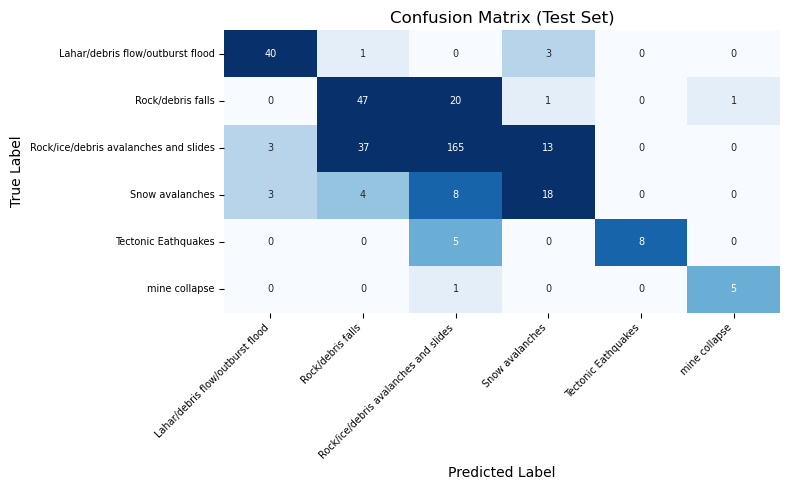

In [111]:
code_to_label_dict = {v: k for k, v in label_to_code_dict.items()}
unique_classes = sorted(list(set(y_test) | set(y_test_predict)))
tick_labels = [code_to_label_dict[code] for code in unique_classes]

cm = confusion_matrix(y_test, y_test_predict, labels=unique_classes)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 7},
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=False, vmin=0, vmax=10,
            )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7, rotation=0)
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

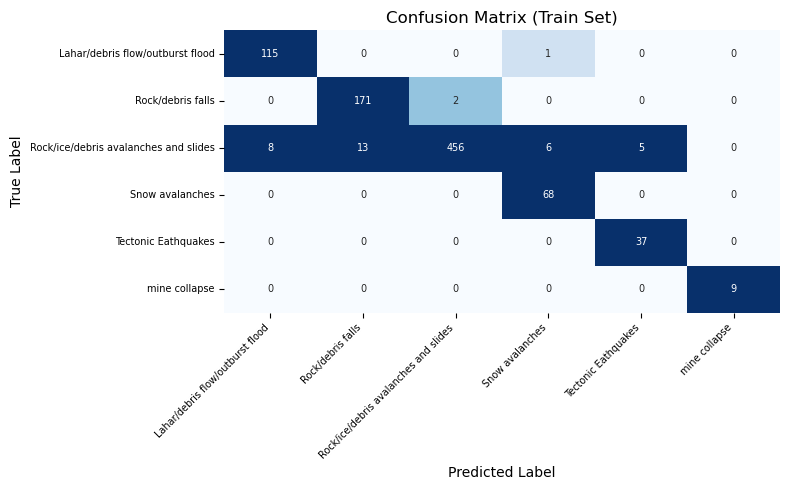

In [112]:
code_to_label_dict = {v: k for k, v in label_to_code_dict.items()}
unique_classes = sorted(list(set(y_train) | set(y_train_predict)))
tick_labels = [code_to_label_dict[code] for code in unique_classes]

cm = confusion_matrix(y_train, y_train_predict, labels=unique_classes)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 7},
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=False, 
            vmin=0, vmax=5, 
            )
            
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(fontsize=7, rotation=45, ha='right') 
plt.yticks(fontsize=7, rotation=0)
plt.title('Confusion Matrix (Train Set)') 
plt.tight_layout()
plt.show()

Shap Importance Computation for Multiclass problem


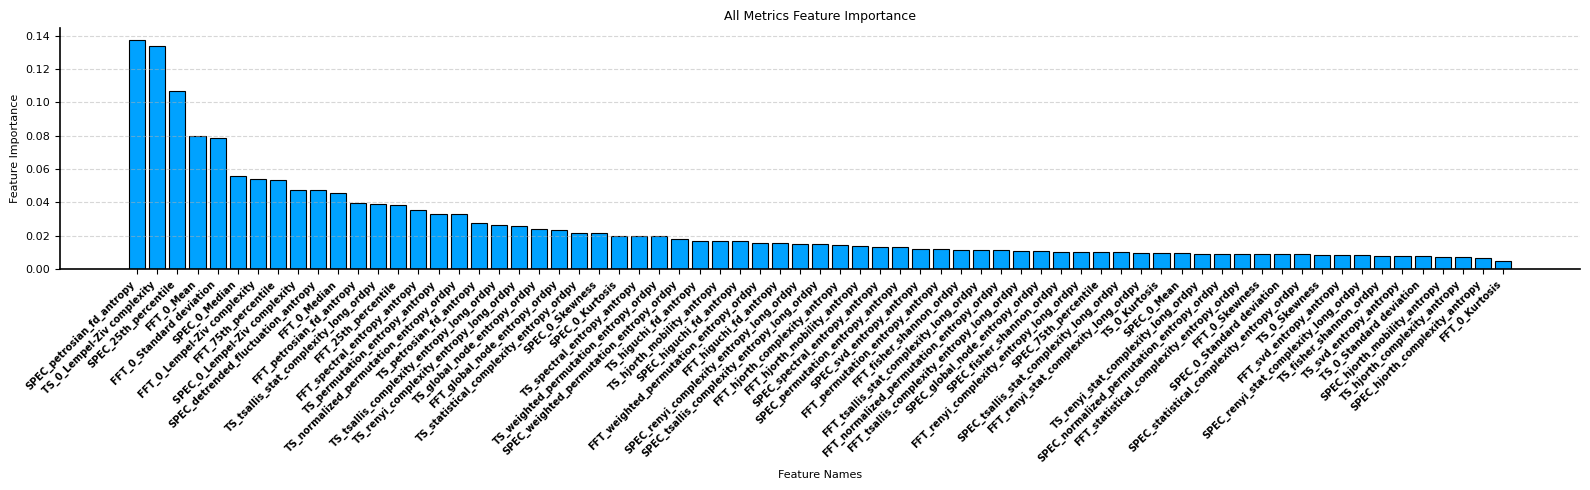

In [113]:
shap.initjs()

explainer = shap.Explainer(classifier)
shap_values = explainer(X_test)
_, feature_imp_df_alldata = HelperFunc.print_feature_importances_shap_values(shap_values, all_features)

plt.figure(figsize=(16, 5))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.bar(feature_imp_df_alldata['index'], feature_imp_df_alldata['vals'], color="#00A2FF", edgecolor='black', linewidth=0.8)
plt.xlabel('Feature Names',fontsize=8); plt.ylabel('Feature Importance',fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=7, fontweight='bold'); plt.yticks(fontsize=8)
plt.title('All Metrics Feature Importance', fontsize=9)
plt.tight_layout()
plt.show()

In [114]:
N_percent = 100
total_features = len(feature_imp_df_alldata)
num_features_to_keep = int(total_features * (N_percent / 100.0))
print(f"Total original features: {total_features}")
print(f"Keeping top {N_percent}%: {num_features_to_keep} features")

shap_selected_features = feature_imp_df_alldata['index'].head(num_features_to_keep).tolist()

Total original features: 69
Keeping top 100%: 69 features


Generating combined plot for 10 features...


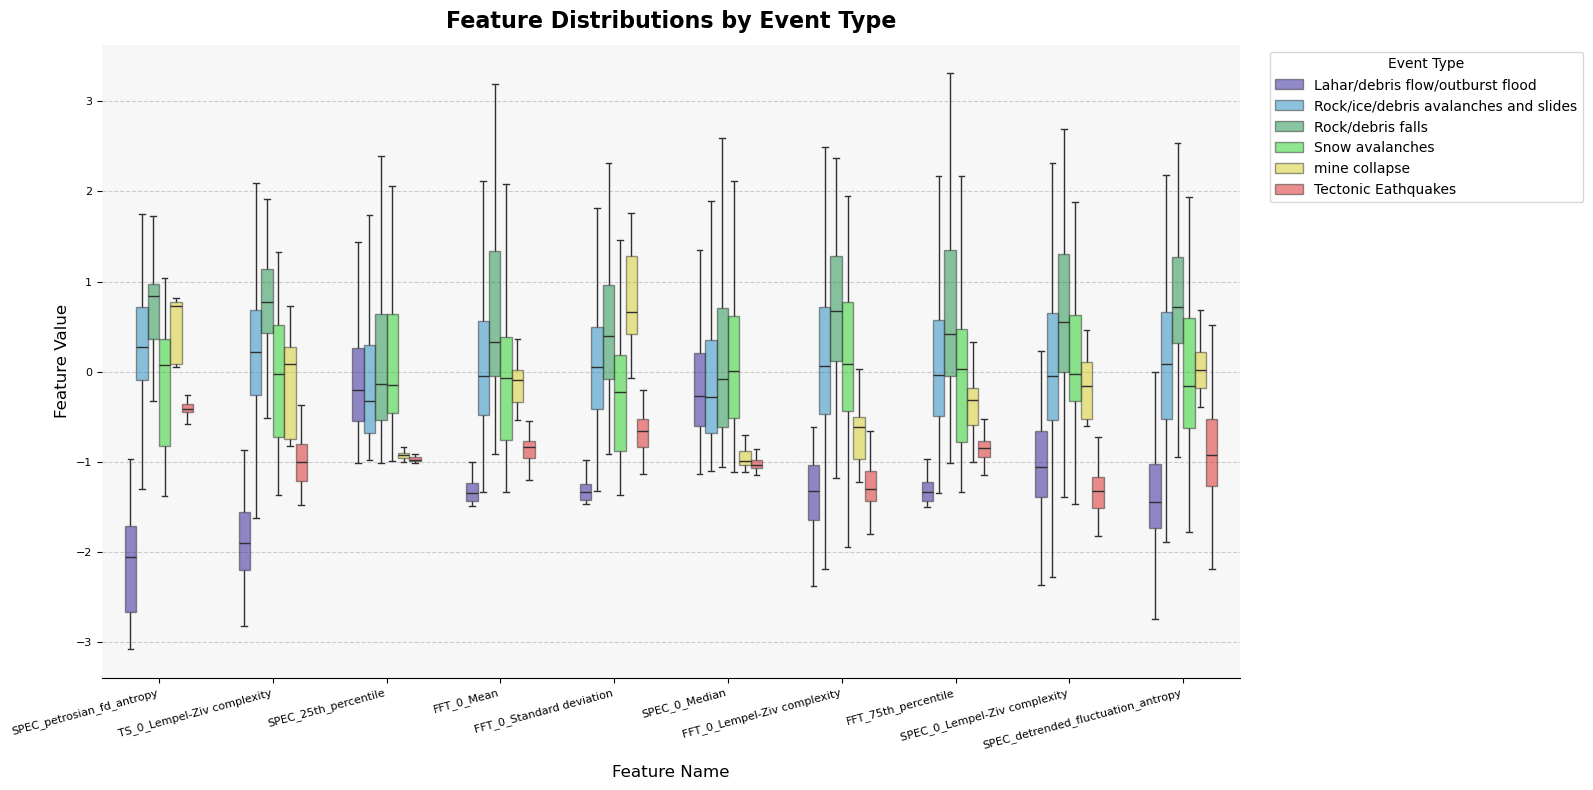

In [115]:
my_features = shap_selected_features[0:10]
_plot_combined_feature_distributions(sepc2vec_df_filt, label_col='subtype', features_to_plot=my_features, use_log_scale=False, show_point_spreads=False)


#### Supervised Clustering On Shap Selected Feature Sets

In [116]:
N_percent = 25
total_features = len(feature_imp_df_alldata)
num_features_to_keep = int(total_features * (N_percent / 100.0))
print(f"Total original features: {total_features}")
print(f"Keeping top {N_percent}%: {num_features_to_keep} features")

shap_columns_to_keep = feature_imp_df_alldata['index'].head(num_features_to_keep).tolist() + ['subtype']
sepc2vec_df_filt_shapcols = sepc2vec_df_filt[shap_columns_to_keep].copy()
print(sepc2vec_df_filt_shapcols.shape)
sepc2vec_df_filt_shapcols.head(2)

Total original features: 69
Keeping top 25%: 17 features
(1274, 18)


,SPEC_petrosian_fd_antropy,TS_0_Lempel-Ziv complexity,SPEC_25th_percentile,FFT_0_Mean,FFT_0_Standard deviation,SPEC_0_Median,FFT_0_Lempel-Ziv complexity,FFT_75th_percentile,SPEC_0_Lempel-Ziv complexity,SPEC_detrended_fluctuation_antropy,FFT_0_Median,FFT_petrosian_fd_antropy,TS_tsallis_stat_complexity_long_ordpy,FFT_25th_percentile,FFT_spectral_entropy_antropy,TS_permutation_entropy_antropy,TS_normalized_permutation_entropy_ordpy,subtype
0,1.010779,0.076734,0.012137,0.001165,0.000917,0.035801,0.086887,0.001674,0.017830,0.909550,0.000949,1.023574,0.262227,0.000425,0.931179,0.822124,0.822124,Lahar/debris flow/outburst flood
1,1.010774,0.069716,0.010461,0.001458,0.001162,0.040821,0.095566,0.001932,0.019713,0.852231,0.001143,1.026261,0.299375,0.000634,0.996071,0.745520,0.745520,Lahar/debris flow/outburst flood


In [117]:
## Performing the Random Forest Classifier on the Data
rf_params = { 'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5,
                'max_features': 'sqrt', 'class_weight': 'balanced_subsample', 'n_jobs': -1, 'random_state': 42}

classifier, all_features, label_to_code_dict, test_dataset, train_dataset = HelperFunc.train_randomforest_on_noisebnk(sepc2vec_df_filt_shapcols, 
                                                                                                                        labelcol='subtype', 
                                                                                                                        test_size=0.3, 
                                                                                                                        standardize=True, 
                                                                                                                        plot_cm=False,
                                                                                                                        rf_params=rf_params)
X_test_index, X_test, y_test, y_test_predict = test_dataset
X_train_index, X_train, y_train, y_train_predict = train_dataset

Standardization applied safely


Model Finished training on 17 features and 891 data points
Accuracy from test set: 73.62924281984334%
Accuracy from train set: 92.81705948372615%


In [118]:
train_accuracy = accuracy_score(y_train, y_train_predict)
test_accuracy = accuracy_score(y_test, y_test_predict)
bal_acc = balanced_accuracy_score(y_test, y_test_predict)
macro_f1 = f1_score(y_test, y_test_predict, average='macro')

print(f"Accuracy from train set: {train_accuracy:.3f}")
print(f"Accuracy from test set: {test_accuracy:.3f}")
print(f"Balanced Accuracy: {bal_acc * 100:.2f}%")
print(f"Macro F1-Score:    {macro_f1:.4f}")

Accuracy from train set: 0.928
Accuracy from test set: 0.736
Balanced Accuracy: 74.34%
Macro F1-Score:    0.7474


#### Unsupervised Clustering

In [45]:
N_percent = 25
total_features = len(feature_imp_df_alldata)
num_features_to_keep = int(total_features * (N_percent / 100.0))
print(f"Total original features: {total_features}")
print(f"Keeping top {N_percent}%: {num_features_to_keep} features")

shap_columns_to_keep = feature_imp_df_alldata['index'].head(num_features_to_keep).tolist() + ['subtype']
sepc2vec_df_filt_shapcols = sepc2vec_df_filt[shap_columns_to_keep].copy()
print(sepc2vec_df_filt_shapcols.shape)
sepc2vec_df_filt_shapcols.head(2)

Total original features: 69
Keeping top 25%: 17 features
(1274, 18)


,SPEC_petrosian_fd_antropy,TS_0_Lempel-Ziv complexity,SPEC_25th_percentile,FFT_0_Mean,FFT_0_Standard deviation,SPEC_0_Median,FFT_0_Lempel-Ziv complexity,FFT_75th_percentile,SPEC_0_Lempel-Ziv complexity,SPEC_detrended_fluctuation_antropy,FFT_0_Median,FFT_petrosian_fd_antropy,TS_tsallis_stat_complexity_long_ordpy,FFT_25th_percentile,FFT_spectral_entropy_antropy,TS_permutation_entropy_antropy,TS_normalized_permutation_entropy_ordpy,subtype
0,1.010779,0.076734,0.012137,0.001165,0.000917,0.035801,0.086887,0.001674,0.017830,0.909550,0.000949,1.023574,0.262227,0.000425,0.931179,0.822124,0.822124,Lahar/debris flow/outburst flood
1,1.010774,0.069716,0.010461,0.001458,0.001162,0.040821,0.095566,0.001932,0.019713,0.852231,0.001143,1.026261,0.299375,0.000634,0.996071,0.745520,0.745520,Lahar/debris flow/outburst flood


##### Standard Clustering

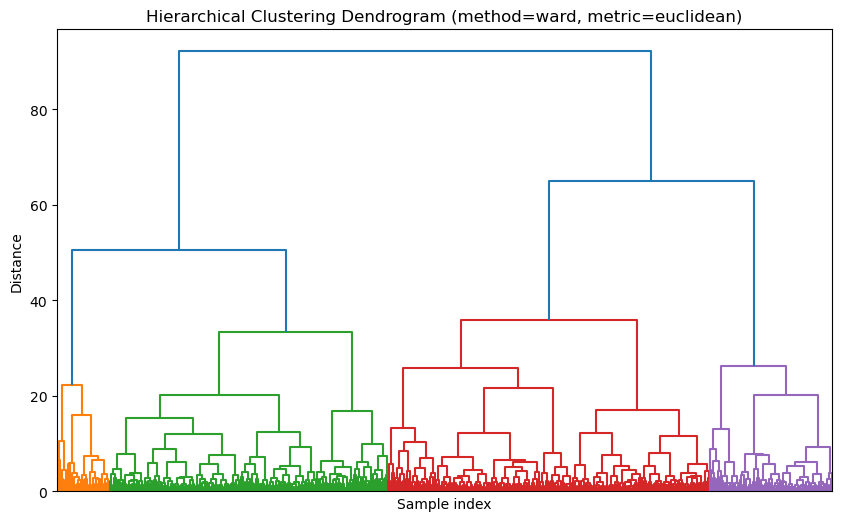

Total Labels:  1274


In [46]:
features_subtype_classes = sepc2vec_df_filt_shapcols.drop(columns=['subtype']).values.astype(np.float32)

scaler = RobustScaler()
features_subtype_classes = scaler.fit_transform(features_subtype_classes)

col_theshold = 48
dist_threshold = 48

cov_matrix = np.cov(features_subtype_classes, rowvar=False)
inv_cov_matrix = np.linalg.pinv(cov_matrix)

linkage_matrix = _perform_hierarchical_clustering(features_subtype_classes, method='ward', metric='euclidean', VI = None,
                                                  plot_dendrogram=True,color_threshold=col_theshold)
hir_labels = _merge_clusters(linkage_matrix, num_clusters=6)
#hir_labels = _merge_clusters(linkage_matrix, distance_threshold=dist_threshold)

print('Total Labels: ', len(hir_labels))


In [47]:
Counter(hir_labels)

Counter({np.int32(2): 340,
         np.int32(4): 302,
         np.int32(5): 227,
         np.int32(6): 201,
         np.int32(3): 118,
         np.int32(1): 86})

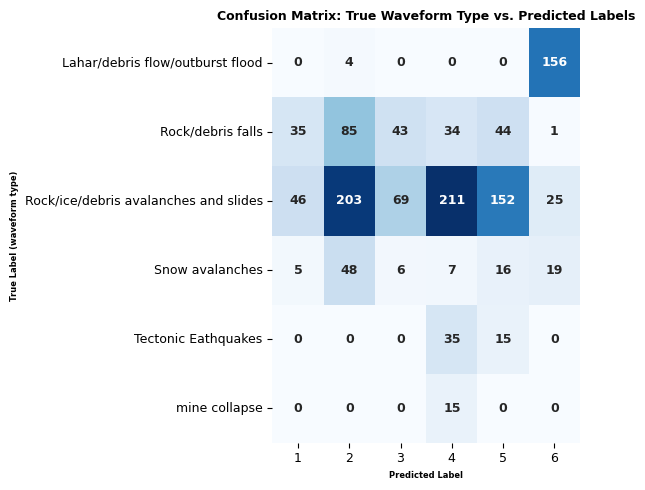

In [48]:
label_map = pd.DataFrame({'labels':hir_labels, 'waveform_type':[name for name in sepc2vec_df_filt_shapcols['subtype'].tolist()]})
label_map.sort_values(by='labels',inplace=True)
label_map = label_map.reset_index(drop=True)

cm = pd.crosstab(label_map['waveform_type'], label_map['labels'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 9, 'fontweight':'bold'}, cbar=False)
plt.title('Confusion Matrix: True Waveform Type vs. Predicted Labels', fontsize=9, fontweight='bold')
plt.ylabel('True Label (waveform type)',fontsize=6, fontweight='bold')
plt.xlabel('Predicted Label',fontsize=6, fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

#### Feature Interpretability: Supplementary Figures 1

In [78]:
def _plot_feature_physics_dashboard(df, x_cols, y_cols, x_labels, y_labels, class_col, unique_classes,spectro_dict, trace_keys, trace_classes,metric_func,metric_name=None,
                                    xlims=None,ylims=None,unique_classes_print=None,log_scale=[False,False,True],savepath=None):
    
    # Map for pretty printing legend labels
    unique_classes_print = unique_classes_print or unique_classes
    print_map = dict(zip(unique_classes, unique_classes_print))
    
    # ==========================================
    # 1. PUBLICATION AESTHETICS SETUP
    # ==========================================
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'axes.linewidth': 0.8,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'axes.labelsize': 10
    })

    # Exact palette requested
    okabe_ito = ["#88bf9c", "#B72818", "#FFB11C", "#4B75FF", "#480058", "#CC79A7"]
    palette = {cls: okabe_ito[i % len(okabe_ito)] for i, cls in enumerate(unique_classes)}

    fig = plt.figure(figsize=(18, 11))
    
    # Main Grid: Top Row (55% height), Bottom Row (45% height)
    gs_main = gridspec.GridSpec(2, 1, height_ratios=[0.5, 0.5], hspace=0.2) # Tightened hspace
    
    # Top Row Grid: 3 Columns for Joint Plots
    gs_top = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_main[0], wspace=0.1) # Tightened wspace

    # ==========================================
    # GLOBAL LEGEND FOR COVARIANCE PLOTS
    # ==========================================
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[c], 
                markersize=9, label=print_map[c]) for c in unique_classes]
    
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.96), 
               ncol=len(unique_classes), frameon=True, fontsize=10)

    # ==========================================
    # 2. ROW 1: THE 3 JOINT PLOTS
    # ==========================================
    for i in range(3):
        # Create a nested 2x2 grid for each joint plot
        gs_joint = gridspec.GridSpecFromSubplotSpec(
            2, 2, subplot_spec=gs_top[i], 
            width_ratios=[5, 1], height_ratios=[1, 5], 
            wspace=0.05, hspace=0.05
        )
        
        ax_main = fig.add_subplot(gs_joint[1, 0])
        ax_top = fig.add_subplot(gs_joint[0, 0], sharex=ax_main)
        ax_right = fig.add_subplot(gs_joint[1, 1], sharey=ax_main)
        
        x_val, y_val = x_cols[i], y_cols[i]
        
        # --- Main Scatter & KDE Overlay ---
        sns.scatterplot(data=df, x=x_val, y=y_val, hue=class_col, palette=palette, 
                        alpha=0.6, edgecolor='white', linewidth=0.3, s=35, ax=ax_main, legend=False)
        
        sns.kdeplot(data=df, x=x_val, y=y_val, hue=class_col, palette=palette, 
                    alpha=0.8, linewidths=1.2, thresh=0.1, levels=2, fill=False, 
                    warn_singular=False, ax=ax_main, legend=False, log_scale=log_scale[i])
        
        # --- Marginals (Density Distributions) ---
        sns.kdeplot(data=df, x=x_val, hue=class_col, palette=palette, fill=True, alpha=0.4, 
                    linewidth=1.0, warn_singular=False, ax=ax_top, legend=False, common_norm=False,log_scale=log_scale[i])
        sns.kdeplot(data=df, y=y_val, hue=class_col, palette=palette, fill=True, alpha=0.4, 
                    linewidth=1.0, warn_singular=False, ax=ax_right, legend=False, common_norm=False,log_scale=log_scale[i])
        
        # --- Aesthetics & Cleanup ---
        ax_main.grid(True, linestyle='--', color='#DDDDDD', zorder=0)
        ax_main.set_axisbelow(True)
        ax_main.set_xlabel(x_labels[i], fontweight='bold')
        ax_main.set_ylabel(y_labels[i], fontweight='bold')
        
        # Apply Custom Limits if provided
        if xlims and i < len(xlims):
            ax_main.set_xlim(xlims[i])
        if ylims and i < len(ylims):
            ax_main.set_ylim(ylims[i])
        
        # Strip all text and labels from marginals
        ax_top.set_xlabel('')
        ax_top.set_ylabel('')
        ax_right.set_xlabel('')
        ax_right.set_ylabel('')
        
        # Remove tick numbers but keep axes aligned
        #ax_top.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
        #ax_right.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
        ax_top.tick_params(axis='both', which='both', labelbottom=False, labelleft=False, labeltop=False, labelright=False, 
                            bottom=True, left=False, top=False, right=False)
        ax_right.tick_params(axis='both', which='both', labelbottom=False, labelleft=False, labeltop=False, labelright=False, 
                                bottom=False, left=True, top=False, right=False)
        
        # Remove Tick VALUES from main joint plot, but keep the marks
        #ax_main.tick_params(labelbottom=False, labelleft=False, bottom=True, left=True)
        ax_main.tick_params(which='both', labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=True, left=True)

        sns.despine(ax=ax_top, left=True, bottom=False)
        sns.despine(ax=ax_right, bottom=True, left=False)
        
        # Global Title for the whole row (Shifted slightly down to account for global legend)
        if i == 0:
            ax_top.text(0, 1.25, "A. Feature Interpretability Covariance (TS, FFT, SPEC)", 
                        transform=ax_top.transAxes, fontsize=12, fontweight='bold')

    # ==========================================
    # 3. ROW 2: TRACES & BAR CHART
    # ==========================================
    # Bottom Row Grid: 2 Columns (60% Traces, 40% Bar Chart)
    gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[1], width_ratios=[0.6, 0.4], wspace=0.1) # Tightened wspace
    
    # Split the left column into rows for the traces
    gs_traces = gridspec.GridSpecFromSubplotSpec(len(trace_keys), 1, subplot_spec=gs_bottom[0], hspace=0.1) # Tightened hspace
    
    flat_vals = []
    hilb_vals = []
    
    for i, (key, cls_name) in enumerate(zip(trace_keys, trace_classes)):
        ax_trace = fig.add_subplot(gs_traces[i])
        
        # Get CWT data
        spectro = spectro_dict.get(key)
        if spectro is not None:
            cwt_mag = np.abs(spectro)
            # Standard threshold gate
            cwt_mag[cwt_mag < np.percentile(cwt_mag, 50)] = 0
            
            # Extract 1D representations
            flat_data = cwt_mag.flatten()
            hilb_data = _ghilbertize_asym_data(cwt_mag)
            
            # Compute user metrics
            val_flat = _compute_metric(flat_data, metric_func, dx=3, sf=20)
            val_hilb = _compute_metric(hilb_data, metric_func, dx=3, sf=20)
            flat_vals.append(val_flat)
            hilb_vals.append(val_hilb)
            
            # Dynamic shift so Flatten trace sits above Hilbert
            shift_amount = np.max(hilb_data) - np.min(flat_data) + 0.15 * (np.max(hilb_data) - np.min(hilb_data) + 1e-6)
            flat_data_shifted = flat_data + shift_amount
            
            # 1. Hilbert (Class Color, Bottom)
            ax_trace.plot(hilb_data, color=palette[cls_name], linewidth=0.8, alpha=1.0)
            # 2. Flattened (Grey, Top)
            ax_trace.plot(flat_data_shifted, color='#999999', linewidth=0.5, alpha=0.5)
            
            ax_trace.set_xlim([0, len(flat_data)])
            
            # Clean up trace axes completely
            sns.despine(ax=ax_trace, left=True, bottom=True)
            ax_trace.set_xticks([])
            ax_trace.set_yticks([])
            
            # Add specific Y-labels floating on the left
            flat_mid = np.mean([np.min(flat_data_shifted), np.max(flat_data_shifted)])
            hilb_mid = np.mean([np.min(hilb_data), np.max(hilb_data)])
            
            #if i==0:
            ax_trace.text(-0.01, flat_mid, "Flat", transform=ax_trace.get_yaxis_transform(), ha='right', va='center', color='black', fontweight='bold', fontsize=8)
            ax_trace.text(-0.01, hilb_mid, "Hilbert", transform=ax_trace.get_yaxis_transform(), ha='right', va='center', color='black', fontweight='bold', fontsize=8)
            
            # Add Class Title strictly matching the covariance colors
            ax_trace.text(0.95, hilb_mid, print_map.get(cls_name, cls_name), transform=ax_trace.get_yaxis_transform(),
                            color=palette[cls_name], ha='center', va='center', fontweight='bold', fontsize=8)
            
            if i == 0:
                #ax_trace.text(0, 1.01, "B. 1D Topologies: Standard Row-Flattening vs. Space-Filling Hilbert", 
                #              transform=ax_trace.transAxes, fontsize=12, fontweight='bold', color='black')
                ax_trace.set_title(f"B. 1D Topologies: Standard Row-Flattening vs. Space-Filling Hilbert", fontsize=12, fontweight='bold', pad=5, loc='left')

    # ==========================================
    # 4. ROW 2 (RIGHT): 2-ROW BAR CHART
    # ==========================================
    # Split the right column into 2 rows for Flat and Hilbert bars
    gs_bars = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_bottom[1], hspace=0.2)
    ax_bar_flat = fig.add_subplot(gs_bars[0])
    ax_bar_hilb = fig.add_subplot(gs_bars[1])
    
    x = np.arange(len(trace_classes))
    width = 0.6  # Wider bars since they are no longer placed side-by-side

    # Color coordinate bars directly to their class
    bar_colors = [palette[cls] for cls in trace_classes]

    # --- Top Bar Chart: Flat ---
    ax_bar_flat.bar(x, flat_vals, label='Flat', color="#999999", alpha=0.5, hatch='//', edgecolor='black', linewidth=0.8)
    ax_bar_flat.set_title(f"C. {metric_name}", fontsize=12, fontweight='bold', pad=5, loc='left')
    ax_bar_flat.set_ylabel("Flat", fontweight='bold', fontsize=11)
    ax_bar_flat.set_xticks([])
    ax_bar_flat.set_yticks([])
    ax_bar_flat.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    #ax_bar_flat.set_axisbelow(True)
    ax_bar_flat.set_yscale('log')
    sns.despine(ax=ax_bar_flat)
    ax_bar_flat.tick_params(axis='both', which='both', labelleft=False, left=False)
    

    # --- Bottom Bar Chart: Hilbert ---
    ax_bar_hilb.bar(x, hilb_vals, width, label='Hilbert', color=bar_colors, alpha=1.0, edgecolor='black', linewidth=0.8)
    ax_bar_hilb.set_ylabel("Hilbert", fontweight='bold', fontsize=11)
    ax_bar_hilb.set_xticks([])
    ax_bar_hilb.set_yticks([])
    ax_bar_hilb.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    #ax_bar_hilb.set_axisbelow(True)
    ax_bar_hilb.set_yscale('log')
    sns.despine(ax=ax_bar_hilb)
    ax_bar_hilb.tick_params(axis='both', which='both', labelleft=False, left=False)

    # ==========================================
    # 5. EXPORT
    # ==========================================
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.08) # Make room for top legend
    
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight', format='png')
        print(f"Saved figure to {savepath}")
        
    plt.show()



In [75]:
save_spectro_dict = np.load("/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/computed_dataset_files/esec_spec2vec_input_cwt_dict.npy", allow_pickle=True).item()
save_spectro_dict_eqs = np.load("/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/computed_dataset_files/tectonic_eq_spec2vec_input_cwt_dict.npy", allow_pickle=True).item()
merged_spectro_dict = save_spectro_dict | save_spectro_dict_eqs
del save_spectro_dict, save_spectro_dict_eqs

In [79]:
X_test_index, X_test, y_test, y_test_predict = test_dataset
X_train_index, X_train, y_train, y_train_predict = train_dataset

code_to_label_dict = {v: k for k, v in label_to_code_dict.items()}
unique_classes = sorted(list(set(y_test) | set(y_test_predict)))
tick_labels = [code_to_label_dict[code] for code in unique_classes]
print(tick_labels)
tick_labels_plot = ['LDO','RD','RDAS','SA','TEQ','MC']

['Lahar/debris flow/outburst flood', 'Rock/debris falls', 'Rock/ice/debris avalanches and slides', 'Snow avalanches', 'Tectonic Eathquakes', 'mine collapse']


/tmp/ipykernel_2262897/1127310499.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure to /data/sswar_files/PRJ_GIS_QA/esce_catalog_test/figures/forpaper_V1/ESEC_FeatureInterpret_Suppl.png


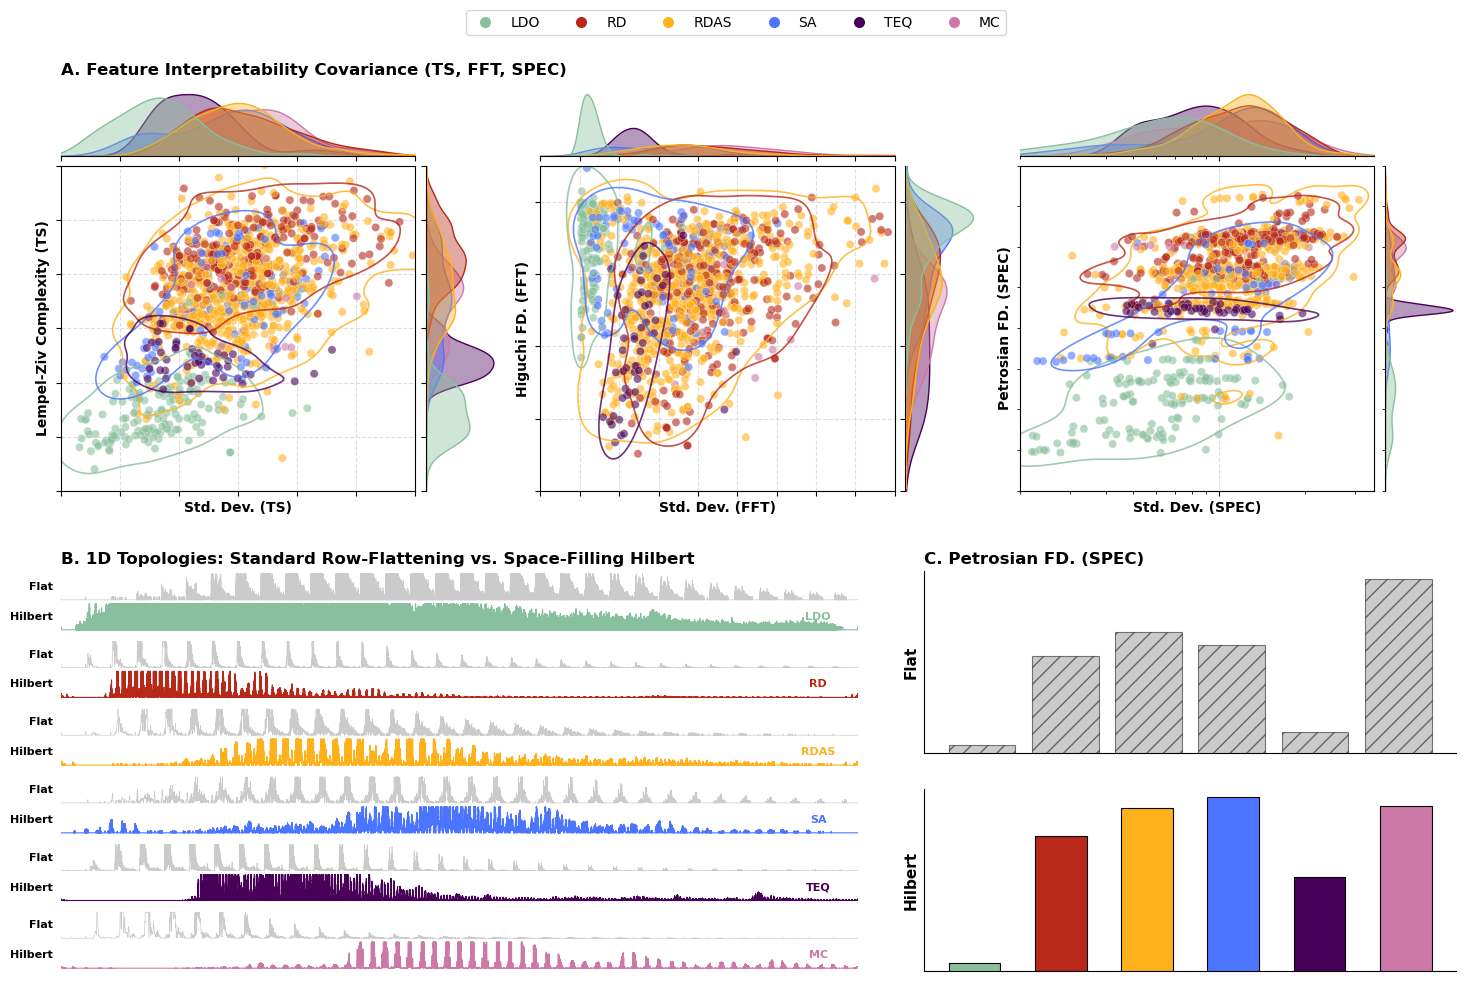

In [82]:
filter_labels = ["305_39_debris_flow_CC_TIMB_EHZ_nan_1.433","71_10_rock_fall_UW_JUN_EHZ_nan_6.247","1017_163_landslide_AV_SPCN_BHZ_nan_9.116",
                "2371_334_snow_avalanche_CC_SUG_BHZ_nan_1.545","az_sio5_bhz_2019_07_06_03_19_53","2128_305_mine_collapse_N4_W50A_HHZ_0.0_88.724"]

_plot_feature_physics_dashboard(
    df=sepc2vec_df_filt, 
    x_cols=['TS_0_Standard deviation', 'FFT_0_Standard deviation', 'SPEC_0_Standard deviation'], 
    y_cols=['TS_0_Lempel-Ziv complexity', 'FFT_higuchi_fd_antropy', 'SPEC_petrosian_fd_antropy'], 
    x_labels=['Std. Dev. (TS)', 'Std. Dev. (FFT)', 'Std. Dev. (SPEC)'], 
    y_labels=['Lempel-Ziv Complexity (TS)', 'Higuchi FD. (FFT)', 'Petrosian FD. (SPEC)'], 
    class_col='subtype', 
    unique_classes=tick_labels,
    spectro_dict=merged_spectro_dict, 
    trace_keys=filter_labels,
    trace_classes=['Lahar/debris flow/outburst flood', 'Rock/debris falls', 'Rock/ice/debris avalanches and slides', 'Snow avalanches', 'Tectonic Eathquakes','mine collapse'], #['Rock/ice/debris avalanches and slides', 'Tectonic Eathquakes']
    metric_func="petrosian_fd",
    metric_name="Petrosian FD. (SPEC)",
    xlims=[(0,0.3),(-0.002,0.016),(0.02,0.35)],
    ylims=[(0.04,0.16),(1.2,2.1),(1.008,1.016)],
    unique_classes_print = tick_labels_plot,
    savepath="/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/figures/forpaper_V1/ESEC_FeatureInterpret_Suppl.png"
)


#### Feature Interpretability: Supplementary Figures 2

In [94]:
save_spectro_dict = np.load("/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/computed_dataset_files/esec_spec2vec_input_cwt_dict.npy", allow_pickle=True).item()
save_spectro_dict_eqs = np.load("/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/computed_dataset_files/tectonic_eq_spec2vec_input_cwt_dict.npy", allow_pickle=True).item()
merged_spectro_dict = save_spectro_dict | save_spectro_dict_eqs
del save_spectro_dict, save_spectro_dict_eqs

In [95]:
ARCHETYPE_LABELS_TMP = ["305_39_debris_flow_CC_TIMB_EHZ_nan_1.433","71_10_rock_fall_UW_JUN_EHZ_nan_6.247","1017_163_landslide_AV_SPCN_BHZ_nan_9.116",
                        "2371_334_snow_avalanche_CC_SUG_BHZ_nan_1.545","az_sio5_bhz_2019_07_06_03_19_53","2128_305_mine_collapse_N4_W50A_HHZ_0.0_88.724"]

ARCHETYPE_SUBTYP_TMP = ['Lahar/debris flow/outburst flood','Rock/debris falls','Rock/ice/debris avalanches and slides','Snow avalanches', 
                        'Tectonic Eathquakes','mine collapse']

AVAILABLE_METRICS = ['permutation_entropy','svd_entropy','spectral_entropy','petrosian_fd','ant_perm_entropy','hjorth_complexity','detrended_fluctuation',
                    'global_node_entropy','fisher_shannon','missing_patterns','higuchi_fd','renyi_complexity_entropy','tsallis_complexity_entropy']

DATA_DIR_LIST = ["/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/esec_processed_vel",
                "/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/final_test_results_for_production/eq_processed_vel"]
                
_plot_comprehensive_4row_dashboard(ARCHETYPE_LABELS_TMP,ARCHETYPE_SUBTYP_TMP,merged_spectro_dict, fs=20.0, 
                                    dx_spec=5, dx_ts=4, dx_fft=4, spec_noise_thresh=50,
                                    data_dir_lst=DATA_DIR_LIST, metric_name="permutation_entropy", 
                                    save_path="/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/figures/forpaper_V1/ESEC_ComprehensiveInterpret_Suppl.png")                             